In [2]:
import sys
import site

print("Python version:", sys.version)
print("Python executable:", sys.executable)
print("Site packages:", site.getsitepackages())

Python version: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Python executable: g:\GOIT\GitHub\goit-dlcv-final\.venv\Scripts\python.exe
Site packages: ['g:\\GOIT\\GitHub\\goit-dlcv-final\\.venv', 'g:\\GOIT\\GitHub\\goit-dlcv-final\\.venv\\lib\\site-packages']


In [ ]:
from pathlib import Path

DATA_DIR = Path("datasets")

print("Поточна робоча папка:")
print(Path.cwd())

print("\nЧи існує папка datasets?")
print(DATA_DIR.exists())

if DATA_DIR.exists():
    print("\nУсі файли та вкладені папки в datasets:\n")

    for path in sorted(DATA_DIR.rglob("*")):
        relative_path = path.relative_to(DATA_DIR)

        if path.is_dir():
            print(f"[DIR]  {relative_path}")
        else:
            size_mb = path.stat().st_size / (1024 * 1024)
            print(f"[FILE] {relative_path} | {size_mb:.2f} MB")
else:
    print(
        "\nПапка 'datasets' не знайдена. "
        "Потрібно уточнити шлях до файлів."
    )

Поточна робоча папка:
g:\GOIT\GitHub\goit-dlcv-final

Чи існує папка datasets?
True

Усі файли та вкладені папки в datasets:

[DIR]  images
[DIR]  images\images
[DIR]  images\images\test
[FILE] images\images\test\0008c5398-1.jpg | 0.02 MB
[FILE] images\images\test\0008c5398-2.jpg | 0.02 MB
[FILE] images\images\test\0008c5398-3.jpg | 0.02 MB
[FILE] images\images\test\0008c5398-4.jpg | 0.02 MB
[FILE] images\images\test\0008c5398-5.jpg | 0.02 MB
[FILE] images\images\test\0008c5398-6.jpg | 0.03 MB
[FILE] images\images\test\004c2f355-1.jpg | 0.02 MB
[FILE] images\images\test\004c2f355-2.jpg | 0.01 MB
[FILE] images\images\test\00553ae55-1.jpg | 0.02 MB
[FILE] images\images\test\00553ae55-2.jpg | 0.01 MB
[FILE] images\images\test\00553ae55-3.jpg | 0.01 MB
[FILE] images\images\test\00553ae55-4.jpg | 0.02 MB
[FILE] images\images\test\00553ae55-5.jpg | 0.01 MB
[FILE] images\images\test\00eca0391-1.jpg | 0.04 MB
[FILE] images\images\test\00eca0391-2.jpg | 0.03 MB
[FILE] images\images\test\00eca03

: 

In [ ]:
# =================================
# Крок 1. Інвентарізація датасету 
# =================================



from pathlib import Path
from collections import Counter

DATA_DIR = Path("datasets")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Папку не знайдено: {DATA_DIR.resolve()}"
    )

all_paths = list(DATA_DIR.rglob("*"))
files = [path for path in all_paths if path.is_file()]
dirs = [path for path in all_paths if path.is_dir()]

print(f"Шлях до датасету: {DATA_DIR.resolve()}")
print(f"Кількість вкладених папок: {len(dirs):,}")
print(f"Кількість файлів: {len(files):,}")

print("\n=== Вміст верхнього рівня datasets ===")
for path in sorted(DATA_DIR.iterdir()):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"[FILE] {path.name} | {size_mb:.2f} MB")
    else:
        file_count = sum(1 for item in path.rglob("*") if item.is_file())
        print(f"[DIR]  {path.name} | файлів: {file_count:,}")

print("\n=== Кількість файлів за розширенням ===")
extension_counts = Counter(
    path.suffix.lower() if path.suffix else "[без розширення]"
    for path in files
)

for extension, count in sorted(extension_counts.items()):
    print(f"{extension}: {count:,}")

print("\n=== Усі CSV-файли ===")
csv_files = sorted(DATA_DIR.rglob("*.csv"))

if csv_files:
    for path in csv_files:
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"{path.relative_to(DATA_DIR)} | {size_mb:.2f} MB")
else:
    print("CSV-файлів не знайдено.")

Шлях до датасету: G:\GOIT\GitHub\goit-dlcv-final\datasets
Кількість вкладених папок: 4
Кількість файлів: 37,923

=== Вміст верхнього рівня datasets ===
[DIR]  images | файлів: 37,920
[FILE] sample_submission.csv | 0.00 MB
[FILE] test.csv | 0.70 MB
[FILE] train.csv | 2.34 MB

=== Кількість файлів за розширенням ===
.csv: 3
.jpg: 37,920

=== Усі CSV-файли ===
sample_submission.csv | 0.00 MB
test.csv | 0.70 MB
train.csv | 2.34 MB


In [4]:
# =====================================
# Крок 2. Попередній аналіз даних (EDA) 
# =====================================


import pandas as pd

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

print("=== РОЗМІРИ ТАБЛИЦЬ ===")
print(f"train: {train.shape[0]:,} рядків × {train.shape[1]} колонок")
print(f"test: {test.shape[0]:,} рядків × {test.shape[1]} колонок")
print(
    f"sample_submission: "
    f"{sample_submission.shape[0]:,} рядків × "
    f"{sample_submission.shape[1]} колонок"
)

print("\n=== КОЛОНКИ train ===")
print(train.columns.tolist())

print("\n=== КОЛОНКИ test ===")
print(test.columns.tolist())

print("\n=== КОЛОНКИ sample_submission ===")
print(sample_submission.columns.tolist())

print("\n=== ТИПИ ДАНИХ train ===")
print(train.dtypes.to_string())

print("\n=== ПЕРШІ 3 РЯДКИ train ===")
display(train.head(3))

print("\n=== ПЕРШІ 3 РЯДКИ test ===")
display(test.head(3))

print("\n=== ПРОПУСКИ У train ===")
missing_train = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)
display(missing_train[missing_train["missing_count"] > 0])

print("\n=== ДУБЛІКАТИ train ===")
print(f"Повні дублікати рядків: {train.duplicated().sum():,}")

if "PetID" in train.columns:
    print(f"Дублікати PetID: {train['PetID'].duplicated().sum():,}")

target_candidates = [
    column for column in train.columns
    if column not in test.columns
]

print("\n=== КАНДИДАТИ НА ЦІЛЬОВУ КОЛОНКУ ===")
print(target_candidates)

for target in target_candidates:
    print(f"\n=== РОЗПОДІЛ ЦІЛІ: {target} ===")
    print(train[target].value_counts(dropna=False).sort_index().to_string())

print("\n=== sample_submission: перші 5 рядків ===")
display(sample_submission.head())

=== РОЗМІРИ ТАБЛИЦЬ ===
train: 6,431 рядків × 3 колонок
test: 1,891 рядків × 2 колонок
sample_submission: 4 рядків × 2 колонок

=== КОЛОНКИ train ===
['PetID', 'Description', 'AdoptionSpeed']

=== КОЛОНКИ test ===
['PetID', 'Description']

=== КОЛОНКИ sample_submission ===
['PetID', 'AdoptionSpeed']

=== ТИПИ ДАНИХ train ===
PetID            object
Description      object
AdoptionSpeed     int64

=== ПЕРШІ 3 РЯДКИ train ===


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2



=== ПЕРШІ 3 РЯДКИ test ===


,PetID,Description
0,6697a7f62,This cute little puppy is looking for a loving...
1,23b64fe21,These 3 puppies was rescued from a mechanic sh...
2,41e824cbe,"Ara needs a forever home! Believe me, he's a r..."



=== ПРОПУСКИ У train ===


,missing_count
Description,5



=== ДУБЛІКАТИ train ===
Повні дублікати рядків: 0
Дублікати PetID: 0

=== КАНДИДАТИ НА ЦІЛЬОВУ КОЛОНКУ ===
['AdoptionSpeed']

=== РОЗПОДІЛ ЦІЛІ: AdoptionSpeed ===
AdoptionSpeed
1    1197
2    1773
3    1328
4    2133

=== sample_submission: перші 5 рядків ===


,PetID,AdoptionSpeed
0,6697a7f62,1
1,23b64fe21,2
2,41e824cbe,3
3,6c3d7237b,4


In [5]:
print("=== РОЗМІРИ ===")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"sample_submission: {sample_submission.shape}")

print("\n=== КОЛОНКИ ===")
print(f"train: {train.columns.tolist()}")
print(f"test: {test.columns.tolist()}")
print(f"sample_submission: {sample_submission.columns.tolist()}")

print("\n=== УЗГОДЖЕНІСТЬ train / test ===")
train_feature_columns = train.drop(columns="AdoptionSpeed").columns.tolist()
test_columns = test.columns.tolist()

print(f"train без цілі: {train_feature_columns}")
print(f"test: {test_columns}")
print(f"Колонки ідентичні: {train_feature_columns == test_columns}")

print("\n=== PetID ===")
print(f"Унікальних PetID у train: {train['PetID'].nunique():,}")
print(f"Унікальних PetID у test: {test['PetID'].nunique():,}")
print(
    "Спільних PetID між train і test: "
    f"{len(set(train['PetID']) & set(test['PetID'])):,}"
)

=== РОЗМІРИ ===
train: (6431, 3)
test: (1891, 2)
sample_submission: (4, 2)

=== КОЛОНКИ ===
train: ['PetID', 'Description', 'AdoptionSpeed']
test: ['PetID', 'Description']
sample_submission: ['PetID', 'AdoptionSpeed']

=== УЗГОДЖЕНІСТЬ train / test ===
train без цілі: ['PetID', 'Description']
test: ['PetID', 'Description']
Колонки ідентичні: True

=== PetID ===
Унікальних PetID у train: 6,431
Унікальних PetID у test: 1,891
Спільних PetID між train і test: 0


In [ ]:
# ==============================================
# Крок 3. Перевірка відповідності PetID ↔ фото
# ==============================================

from pathlib import Path
from collections import Counter

TRAIN_IMAGES_DIR = DATA_DIR / "images" / "images" / "train"
TEST_IMAGES_DIR = DATA_DIR / "images" / "images" / "test"

if not TRAIN_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Не знайдено: {TRAIN_IMAGES_DIR.resolve()}")

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Не знайдено: {TEST_IMAGES_DIR.resolve()}")

train_image_paths = sorted(TRAIN_IMAGES_DIR.glob("*.jpg"))
test_image_paths = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

print("=== ШЛЯХИ ДО ФОТО ===")
print(f"train images: {TRAIN_IMAGES_DIR.resolve()}")
print(f"test images:  {TEST_IMAGES_DIR.resolve()}")

print("\n=== КІЛЬКІСТЬ ФОТО ===")
print(f"JPG у train: {len(train_image_paths):,}")
print(f"JPG у test:  {len(test_image_paths):,}")
print(f"Разом JPG:   {len(train_image_paths) + len(test_image_paths):,}")

print("\n=== ПРИКЛАДИ НАЗВ ФАЙЛІВ ===")
print("train:")
for path in train_image_paths[:10]:
    print(f"  {path.name}")

print("test:")
for path in test_image_paths[:10]:
    print(f"  {path.name}")

def get_pet_id_from_image_path(image_path: Path) -> str:
    return image_path.stem.rsplit("-", maxsplit=1)[0]

train_images_per_pet = Counter(
    get_pet_id_from_image_path(path)
    for path in train_image_paths
)

test_images_per_pet = Counter(
    get_pet_id_from_image_path(path)
    for path in test_image_paths
)

train_pet_ids = set(train["PetID"])
test_pet_ids = set(test["PetID"])

train_image_pet_ids = set(train_images_per_pet)
test_image_pet_ids = set(test_images_per_pet)

print("\n=== ВІДПОВІДНІСТЬ PetID І ФОТО ===")
print(
    "PetID train без фото: "
    f"{len(train_pet_ids - train_image_pet_ids):,}"
)
print(
    "PetID test без фото: "
    f"{len(test_pet_ids - test_image_pet_ids):,}"
)
print(
    "PetID фото train, яких немає у train.csv: "
    f"{len(train_image_pet_ids - train_pet_ids):,}"
)
print(
    "PetID фото test, яких немає у test.csv: "
    f"{len(test_image_pet_ids - test_pet_ids):,}"
)

print("\n=== РОЗПОДІЛ КІЛЬКОСТІ ФОТО НА ОДИН PetID ===")
print("train:")
for photo_count, pet_count in sorted(Counter(train_images_per_pet.values()).items()):
    print(f"  {photo_count} фото: {pet_count:,} PetID")

print("test:")
for photo_count, pet_count in sorted(Counter(test_images_per_pet.values()).items()):
    print(f"  {photo_count} фото: {pet_count:,} PetID")

print("\n=== ПРИКЛАДИ PetID БЕЗ ФОТО ===")
print("train:", sorted(train_pet_ids - train_image_pet_ids)[:10])
print("test:", sorted(test_pet_ids - test_image_pet_ids)[:10])

print("\n=== ФОТО ДЛЯ ПЕРШИХ 5 PetID ІЗ train.csv ===")
for pet_id in train["PetID"].head(5):
    photo_names = [
        path.name
        for path in train_image_paths
        if get_pet_id_from_image_path(path) == pet_id
    ]
    print(f"{pet_id}: {photo_names}")

=== ШЛЯХИ ДО ФОТО ===
train images: G:\GOIT\GitHub\goit-dlcv-final\datasets\images\images\train
test images:  G:\GOIT\GitHub\goit-dlcv-final\datasets\images\images\test

=== КІЛЬКІСТЬ ФОТО ===
JPG у train: 28,472
JPG у test:  9,448
Разом JPG:   37,920

=== ПРИКЛАДИ НАЗВ ФАЙЛІВ ===
train:
  000a290e4-1.jpg
  000a290e4-2.jpg
  000fb9572-1.jpg
  000fb9572-2.jpg
  000fb9572-3.jpg
  000fb9572-4.jpg
  000fb9572-5.jpg
  000fb9572-6.jpg
  001b1507c-1.jpg
  001b1507c-2.jpg
test:
  0008c5398-1.jpg
  0008c5398-2.jpg
  0008c5398-3.jpg
  0008c5398-4.jpg
  0008c5398-5.jpg
  0008c5398-6.jpg
  004c2f355-1.jpg
  004c2f355-2.jpg
  00553ae55-1.jpg
  00553ae55-2.jpg

=== ВІДПОВІДНІСТЬ PetID І ФОТО ===
PetID train без фото: 0
PetID test без фото: 4
PetID фото train, яких немає у train.csv: 0
PetID фото test, яких немає у test.csv: 12

=== РОЗПОДІЛ КІЛЬКОСТІ ФОТО НА ОДИН PetID ===
train:
  1 фото: 1,124 PetID
  2 фото: 1,006 PetID
  3 фото: 1,084 PetID
  4 фото: 846 PetID
  5 фото: 1,019 PetID
  6 фото: 304

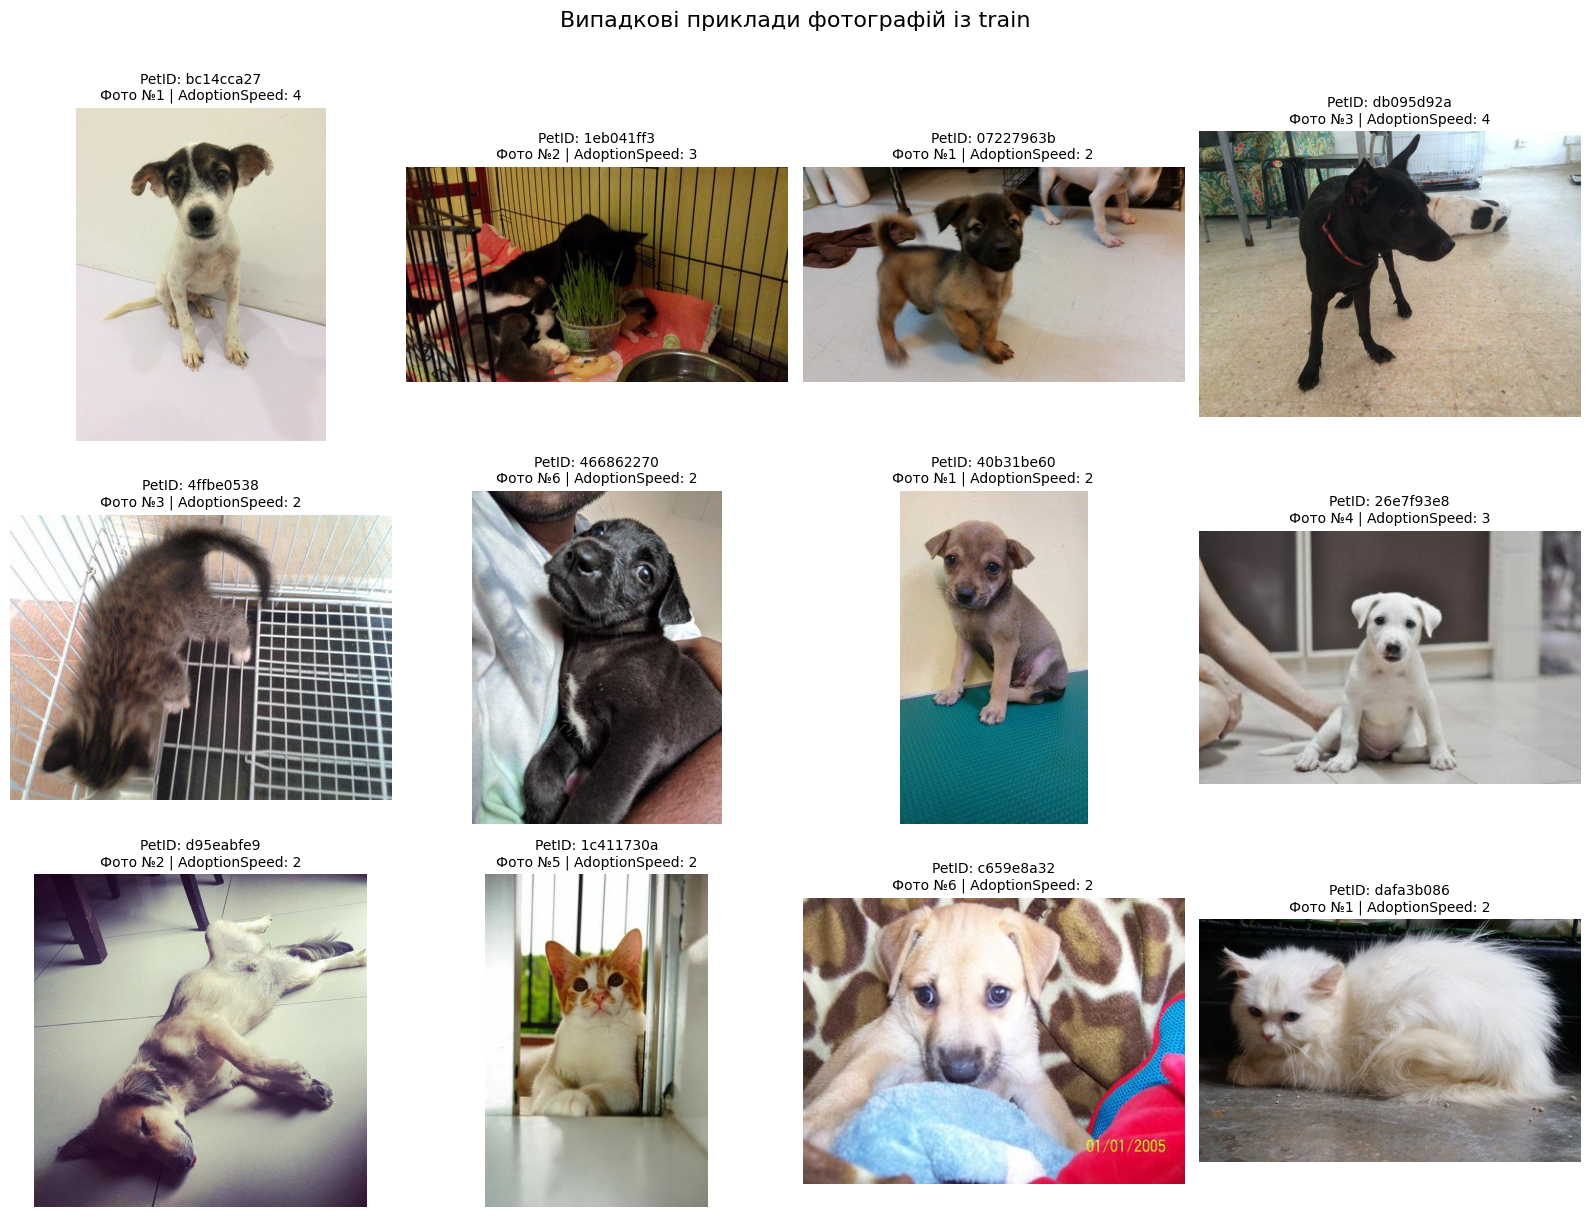

=== ВИБІРКА ДЛЯ ПЕРЕВІРКИ ===
Перевірено зображень: 300
Коректно відкрито: 300
Пошкоджених / недоступних: 0

=== РОЗМІРИ ЗОБРАЖЕНЬ ===
Ширина: min=127, max=640, mean=413.9
Висота: min=220, max=640, mean=399.1

=== РЕЖИМИ КОЛЬОРУ ===
RGB: 300

=== РОЗМІР JPG-ФАЙЛІВ ===
min=6.9 KB, max=98.5 KB, mean=28.4 KB

=== ПРИКЛАДИ РОЗМІРІВ ===
[(640, 480), (400, 300), (640, 360), (360, 480), (400, 301), (203, 360), (640, 480), (360, 480), (300, 400), (300, 400), (203, 360), (360, 480), (270, 480), (640, 505), (270, 480)]

=== ПОШКОДЖЕНІ ФАЙЛИ ===
Не знайдено.


In [10]:
# ==================================================================
# Крок 4. Приклади фото та перевірка якості та розмірів JPG-файлів
# ==================================================================

import random
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image, ImageOps, UnidentifiedImageError

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Скільки зразків показати у notebook.
N_IMAGES_TO_SHOW = 12

# Розмір вибірки для технічної перевірки.
N_TRAIN_TO_CHECK = 200
N_TEST_TO_CHECK = 100

# Випадкові фото з train для візуалізації.
display_paths = random.sample(
    train_image_paths,
    k=min(N_IMAGES_TO_SHOW, len(train_image_paths))
)

# Показуємо 12 зображень у сітці 3 × 4.
n_cols = 4
n_rows = (len(display_paths) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for axis, image_path in zip(axes, display_paths):
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        axis.imshow(image)

    pet_id = get_pet_id_from_image_path(image_path)
    photo_number = image_path.stem.rsplit("-", maxsplit=1)[1]

    adoption_speed = train.loc[
        train["PetID"] == pet_id,
        "AdoptionSpeed"
    ].iloc[0]

    axis.set_title(
        f"PetID: {pet_id}\n"
        f"Фото №{photo_number} | AdoptionSpeed: {adoption_speed}",
        fontsize=10
    )
    axis.axis("off")

# Приховуємо порожні комірки, якщо їх залишиться більше ніж фото.
for axis in axes[len(display_paths):]:
    axis.axis("off")

plt.suptitle(
    "Випадкові приклади фотографій із train",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

# Технічна перевірка: 200 train + 100 test.
sample_train_paths = random.sample(
    train_image_paths,
    k=min(N_TRAIN_TO_CHECK, len(train_image_paths))
)

sample_test_paths = random.sample(
    test_image_paths,
    k=min(N_TEST_TO_CHECK, len(test_image_paths))
)

sample_image_paths = sample_train_paths + sample_test_paths

image_sizes = []
image_modes = Counter()
broken_images = []
file_sizes_kb = []

for image_path in sample_image_paths:
    try:
        file_sizes_kb.append(image_path.stat().st_size / 1024)

        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image)
            image_sizes.append(image.size)
            image_modes[image.mode] += 1

    except (UnidentifiedImageError, OSError, ValueError) as error:
        broken_images.append((image_path.name, str(error)))

widths = [width for width, height in image_sizes]
heights = [height for width, height in image_sizes]

print("=== ВИБІРКА ДЛЯ ПЕРЕВІРКИ ===")
print(f"Перевірено зображень: {len(sample_image_paths):,}")
print(f"Коректно відкрито: {len(image_sizes):,}")
print(f"Пошкоджених / недоступних: {len(broken_images):,}")

print("\n=== РОЗМІРИ ЗОБРАЖЕНЬ ===")
print(
    f"Ширина: min={min(widths)}, max={max(widths)}, "
    f"mean={sum(widths) / len(widths):.1f}"
)
print(
    f"Висота: min={min(heights)}, max={max(heights)}, "
    f"mean={sum(heights) / len(heights):.1f}"
)

print("\n=== РЕЖИМИ КОЛЬОРУ ===")
for mode, count in image_modes.most_common():
    print(f"{mode}: {count:,}")

print("\n=== РОЗМІР JPG-ФАЙЛІВ ===")
print(
    f"min={min(file_sizes_kb):.1f} KB, "
    f"max={max(file_sizes_kb):.1f} KB, "
    f"mean={sum(file_sizes_kb) / len(file_sizes_kb):.1f} KB"
)

print("\n=== ПРИКЛАДИ РОЗМІРІВ ===")
print(image_sizes[:15])

print("\n=== ПОШКОДЖЕНІ ФАЙЛИ ===")
if broken_images:
    for image_name, error in broken_images[:10]:
        print(f"{image_name}: {error}")
else:
    print("Не знайдено.")

=== ПРОПУСКИ Й ПОРОЖНІ ОПИСИ ===
train — пропуски Description: 5
train — порожні описи після очищення: 5
test — пропуски Description: 1
test — порожні описи після очищення: 1

=== ЗАГАЛЬНА ТЕКСТОВА СТАТИСТИКА ===


,train_chars,train_words,test_chars,test_words
count,6431.00,6431.00,1891.00,1891.00
mean,364.16,67.44,372.54,69.32
std,410.72,76.09,409.41,76.61
min,0.00,0.00,0.00,0.00
25%,124.00,22.00,128.00,23.00
50%,250.00,46.00,267.00,49.00
75%,455.00,85.00,466.50,89.00
max,5798.00,1153.00,6664.00,1257.00



=== ТЕКСТОВА СТАТИСТИКА ЗА КЛАСОМ ===


,count,empty_descriptions,mean_chars,median_chars,mean_words,median_words
AdoptionSpeed,,,,,,
1,1197,1,367.93,262.0,68.48,49.0
2,1773,2,372.59,247.0,68.67,46.0
3,1328,1,388.77,272.0,71.70,50.5
4,2133,1,339.71,230.0,63.19,43.0


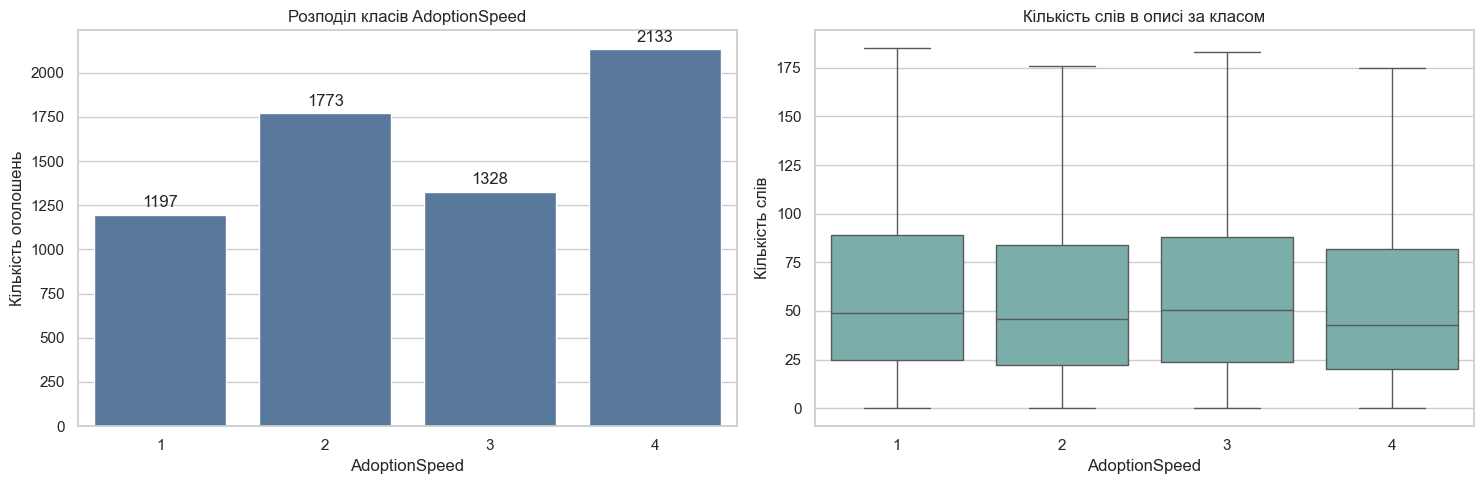


=== ПРИКЛАДИ ОЧИЩЕНИХ ОПИСІВ ===

PetID: d3b4f29f8 | AdoptionSpeed: 2
Mayleen and Flo are two lovely adorable sisters. They are very friendly and affectionate, but wary of strangers and make good watchdogs. Mayleen has golden hues on her face, making her a husky look-alike. Flo has a darker face with brown feet, and is

PetID: e9dc82251 | AdoptionSpeed: 2
A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and playful. Free spaying and neutering can be arrange for owners who adopts them. For more info, p

PetID: 8111f6d4a | AdoptionSpeed: 2
Two-and-a-half month old girl. Very manja and cute.


In [ ]:
# ================================
# Крок 5. Аналіз текстових даних.
# ================================



import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TEXT_COLUMN = "Description"
TARGET_COLUMN = "AdoptionSpeed"

def clean_text(value) -> str:
    """Безпечна мінімальна очистка тексту для EDA."""
    if pd.isna(value):
        return ""

    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for dataframe in (train, test):
    dataframe["Description_clean"] = dataframe[TEXT_COLUMN].apply(clean_text)

    dataframe["description_chars"] = (
        dataframe["Description_clean"].str.len()
    )

    dataframe["description_words"] = (
        dataframe["Description_clean"]
        .str.split()
        .str.len()
        .fillna(0)
        .astype(int)
    )

    dataframe["has_description"] = (
        dataframe["description_chars"] > 0
    ).astype(int)

print("=== ПРОПУСКИ Й ПОРОЖНІ ОПИСИ ===")
print(
    f"train — пропуски Description: "
    f"{train[TEXT_COLUMN].isna().sum():,}"
)
print(
    f"train — порожні описи після очищення: "
    f"{(train['has_description'] == 0).sum():,}"
)
print(
    f"test — пропуски Description: "
    f"{test[TEXT_COLUMN].isna().sum():,}"
)
print(
    f"test — порожні описи після очищення: "
    f"{(test['has_description'] == 0).sum():,}"
)

print("\n=== ЗАГАЛЬНА ТЕКСТОВА СТАТИСТИКА ===")
text_summary = pd.DataFrame(
    {
        "train_chars": train["description_chars"].describe(),
        "train_words": train["description_words"].describe(),
        "test_chars": test["description_chars"].describe(),
        "test_words": test["description_words"].describe(),
    }
)
display(text_summary.round(2))

print("\n=== ТЕКСТОВА СТАТИСТИКА ЗА КЛАСОМ ===")
class_text_summary = (
    train.groupby(TARGET_COLUMN)
    .agg(
        count=("PetID", "count"),
        empty_descriptions=("has_description", lambda s: (s == 0).sum()),
        mean_chars=("description_chars", "mean"),
        median_chars=("description_chars", "median"),
        mean_words=("description_words", "mean"),
        median_words=("description_words", "median"),
    )
    .round(2)
)

display(class_text_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

class_order = sorted(train[TARGET_COLUMN].unique())

sns.countplot(
    data=train,
    x=TARGET_COLUMN,
    order=class_order,
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Розподіл класів AdoptionSpeed")
axes[0].set_xlabel("AdoptionSpeed")
axes[0].set_ylabel("Кількість оголошень")

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

sns.boxplot(
    data=train,
    x=TARGET_COLUMN,
    y="description_words",
    order=class_order,
    ax=axes[1],
    color="#72B7B2",
    showfliers=False
)

axes[1].set_title("Кількість слів в описі за класом")
axes[1].set_xlabel("AdoptionSpeed")
axes[1].set_ylabel("Кількість слів")

plt.tight_layout()
plt.show()

print("\n=== ПРИКЛАДИ ОЧИЩЕНИХ ОПИСІВ ===")
for index, row in train[
    ["PetID", TARGET_COLUMN, "Description_clean"]
].head(3).iterrows():
    preview = row["Description_clean"][:250]
    print(
        f"\nPetID: {row['PetID']} | "
        f"AdoptionSpeed: {row[TARGET_COLUMN]}"
    )
    print(preview if preview else "[порожній опис]")

In [ ]:
# ================================================================
# Крок 6. Розбиття train на train / valid та контроль метрики QWK
# ================================================================


from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score

RANDOM_SEED = 42
TARGET_COLUMN = "AdoptionSpeed"

X = train.drop(columns=[TARGET_COLUMN]).copy()
y = train[TARGET_COLUMN].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

def evaluate_qwk(y_true, y_pred) -> float:
    """Повертає Quadratic Weighted Kappa для цілих класів."""
    return cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

print("=== РОЗМІРИ SPLIT ===")
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_valid: {y_valid.shape}")

print("\n=== РОЗПОДІЛ КЛАСІВ ===")
split_distribution = pd.DataFrame(
    {
        "full_train": y.value_counts(normalize=True).sort_index(),
        "train_split": y_train.value_counts(normalize=True).sort_index(),
        "valid_split": y_valid.value_counts(normalize=True).sort_index(),
    }
)

display((split_distribution * 100).round(2))

print("\n=== КІЛЬКІСТЬ СПОСТЕРЕЖЕНЬ ЗА КЛАСАМИ ===")
split_counts = pd.DataFrame(
    {
        "full_train": y.value_counts().sort_index(),
        "train_split": y_train.value_counts().sort_index(),
        "valid_split": y_valid.value_counts().sort_index(),
    }
)

display(split_counts)

# Контрольний приклад: ідеальний прогноз має QWK = 1.0.
perfect_qwk = evaluate_qwk(y_valid, y_valid)

# Наївний baseline: завжди передбачає найчастіший клас 4.
majority_class = y_train.mode().iloc[0]
majority_predictions = np.full(
    shape=len(y_valid),
    fill_value=majority_class,
    dtype=int
)
majority_qwk = evaluate_qwk(y_valid, majority_predictions)

print("\n=== КОНТРОЛЬ МЕТРИКИ QWK ===")
print(f"Ідеальний прогноз: {perfect_qwk:.4f}")
print(f"Найчастіший клас: {majority_class}")
print(f"QWK наївного baseline: {majority_qwk:.4f}")

=== РОЗМІРИ SPLIT ===
X_train: (5144, 6)
X_valid: (1287, 6)
y_train: (5144,)
y_valid: (1287,)

=== РОЗПОДІЛ КЛАСІВ ===


,full_train,train_split,valid_split
AdoptionSpeed,,,
1,18.61,18.62,18.57
2,27.57,27.57,27.58
3,20.65,20.65,20.67
4,33.17,33.16,33.18



=== КІЛЬКІСТЬ СПОСТЕРЕЖЕНЬ ЗА КЛАСАМИ ===


,full_train,train_split,valid_split
AdoptionSpeed,,,
1,1197,958,239
2,1773,1418,355
3,1328,1062,266
4,2133,1706,427



=== КОНТРОЛЬ МЕТРИКИ QWK ===
Ідеальний прогноз: 1.0000
Найчастіший клас: 4
QWK наївного baseline: 0.0000


In [13]:
# ======================================
# Крок 7. TF-IDF + Logistic Regression
# ======================================


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TEXT_FEATURE_COLUMN = "Description_clean"

# Беремо тільки очищений опис.
train_texts = X_train[TEXT_FEATURE_COLUMN].fillna("")
valid_texts = X_valid[TEXT_FEATURE_COLUMN].fillna("")

# TF-IDF навчаємо виключно на train частині.
# Це важливо: validation не повинна впливати на словник чи IDF-ваги.
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=30_000,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_tfidf = tfidf.fit_transform(train_texts)
X_valid_tfidf = tfidf.transform(valid_texts)

print("=== TF-IDF МАТРИЦІ ===")
print(f"X_train_tfidf: {X_train_tfidf.shape}")
print(f"X_valid_tfidf: {X_valid_tfidf.shape}")
print(f"Розмір словника: {len(tfidf.vocabulary_):,}")

text_model = LogisticRegression(
    C=1.0,
    max_iter=2_000,
    class_weight="balanced",
    solver="lbfgs",
    multi_class="multinomial",
    random_state=RANDOM_SEED
)

text_model.fit(X_train_tfidf, y_train)

valid_pred_text = text_model.predict(X_valid_tfidf)

text_qwk = evaluate_qwk(y_valid, valid_pred_text)
text_accuracy = accuracy_score(y_valid, valid_pred_text)

print("\n=== РЕЗУЛЬТАТ TEXT BASELINE ===")
print(f"QWK: {text_qwk:.4f}")
print(f"Accuracy: {text_accuracy:.4f}")

print("\n=== РОЗПОДІЛ ПРОГНОЗІВ ===")
print(
    pd.Series(valid_pred_text)
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n=== CONFUSION MATRIX ===")
conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_text,
    labels=[1, 2, 3, 4]
)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(conf_matrix_df)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_valid,
        valid_pred_text,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

=== TF-IDF МАТРИЦІ ===
X_train_tfidf: (5144, 30000)
X_valid_tfidf: (1287, 30000)
Розмір словника: 30,000


g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== РЕЗУЛЬТАТ TEXT BASELINE ===
QWK: 0.3026
Accuracy: 0.4250

=== РОЗПОДІЛ ПРОГНОЗІВ ===
1    256
2    298
3    265
4    468

=== CONFUSION MATRIX ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,84,60,35,60
Факт: 2,77,121,73,84
Факт: 3,39,61,92,74
Факт: 4,56,56,65,250



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1     0.3281    0.3515    0.3394       239
           2     0.4060    0.3408    0.3706       355
           3     0.3472    0.3459    0.3465       266
           4     0.5342    0.5855    0.5587       427

    accuracy                         0.4250      1287
   macro avg     0.4039    0.4059    0.4038      1287
weighted avg     0.4219    0.4250    0.4222      1287



#### Аналіз текстового baseline

TF-IDF 
Модель побудувала матриці:
- train: (5144, 30000)
- validation: (1287, 30000)

Тобто використано максимальні 30 000 текстових ознак — слів і біграм.

#### Помилки класів
Confusion matrix:

| Факт \ Прогноз  | 1  | 2   | 3  | 4   |
| --------------- | -- | --- | -- | --- |
| 1               | 84 | 60  | 35 | 60  |
| 2               | 77 | 121 | 73 | 84  |
| 3               | 39 | 61  | 92 | 74  |
| 4               | 56 | 56  | 65 | 250 |

#### Основні висновки:

- Найкраще текстова модель визначає клас 4: recall = 0.5855, F1 = 0.5587.
- Найгірше — клас 1: F1 = 0.3394.
- Модель плутає сусідні класи, але також досить часто відносить швидкі адопції (1) до найповільнішого класу (4): 60 випадків.

In [14]:
experiments = pd.DataFrame(
    [
        {
            "experiment": "text_tfidf_logreg",
            "features": "Description_clean, TF-IDF (1, 2)",
            "model": "LogisticRegression",
            "qwk": text_qwk,
            "accuracy": text_accuracy,
            "notes": "Перший text-only baseline"
        }
    ]
)

display(experiments.round(4))

,experiment,features,model,qwk,accuracy,notes
0,text_tfidf_logreg,"Description_clean, TF-IDF (1, 2)",LogisticRegression,0.3026,0.425,Перший text-only baseline


In [ ]:
# ================================================
# Крок 8. smoke test EfficientNet на одному фото
# ================================================

import torch
import timm
from PIL import Image, ImageOps
from timm.data import create_transform, resolve_data_config

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Легкий і надійний pretrained encoder для першого image baseline.
IMAGE_MODEL_NAME = "efficientnet_b0.ra_in1k"

image_model = timm.create_model(
    IMAGE_MODEL_NAME,
    pretrained=True,
    num_classes=0
)

image_model = image_model.to(DEVICE)
image_model.eval()

data_config = resolve_data_config(
    image_model.pretrained_cfg,
    model=image_model
)

image_transform = create_transform(
    **data_config,
    is_training=False
)

print("=== DEVICE ===")
print(DEVICE)

print("\n=== IMAGE MODEL ===")
print(IMAGE_MODEL_NAME)
print(f"Кількість параметрів: {sum(p.numel() for p in image_model.parameters()):,}")

print("\n=== ПАРАМЕТРИ ПЕРЕТВОРЕННЯ ===")
print(f"input_size: {data_config['input_size']}")
print(f"interpolation: {data_config['interpolation']}")
print(f"mean: {data_config['mean']}")
print(f"std: {data_config['std']}")

# Беремо перше фото з train, яке вже було знайдено раніше.
sample_image_path = train_image_paths[0]

with Image.open(sample_image_path) as image:
    image = ImageOps.exif_transpose(image).convert("RGB")
    image_tensor = image_transform(image).unsqueeze(0).to(DEVICE)

with torch.inference_mode():
    sample_embedding = image_model(image_tensor)

print("\n=== SMOKE TEST ===")
print(f"Файл: {sample_image_path.name}")
print(f"Вхідний tensor: {tuple(image_tensor.shape)}")
print(f"Embedding: {tuple(sample_embedding.shape)}")
print(f"Embedding device: {sample_embedding.device}")
print(f"Є NaN: {torch.isnan(sample_embedding).any().item()}")
print(f"Є Inf: {torch.isinf(sample_embedding).any().item()}")

g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eugen\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article:

=== DEVICE ===
cuda

=== IMAGE MODEL ===
efficientnet_b0.ra_in1k
Кількість параметрів: 4,007,548

=== ПАРАМЕТРИ ПЕРЕТВОРЕННЯ ===
input_size: (3, 224, 224)
interpolation: bicubic
mean: (0.485, 0.456, 0.406)
std: (0.229, 0.224, 0.225)

=== SMOKE TEST ===
Файл: 000a290e4-1.jpg
Вхідний tensor: (1, 3, 224, 224)
Embedding: (1, 1280)
Embedding device: cuda:0
Є NaN: False
Є Inf: False


In [16]:
# ========================================================
# Крок 8.1 PetID → відсортований список шляхів до фото
# ========================================================



from collections import defaultdict
from pathlib import Path

MAX_IMAGES_PER_PET = 5

def get_image_number(image_path: Path) -> int:
    """Повертає числовий номер фото з імені PetID-номер.jpg."""
    return int(image_path.stem.rsplit("-", maxsplit=1)[1])

def build_image_index(image_paths, max_images_per_pet=MAX_IMAGES_PER_PET):
    """
    Групує фото за PetID, числово сортує та залишає
    не більше max_images_per_pet зображень на один профіль.
    """
    image_index = defaultdict(list)

    for image_path in image_paths:
        pet_id = get_pet_id_from_image_path(image_path)
        image_index[pet_id].append(image_path)

    for pet_id in image_index:
        image_index[pet_id] = sorted(
            image_index[pet_id],
            key=get_image_number
        )[:max_images_per_pet]

    return dict(image_index)

train_image_index = build_image_index(train_image_paths)
test_image_index = build_image_index(test_image_paths)

train_selected_photo_counts = [
    len(train_image_index.get(pet_id, []))
    for pet_id in train["PetID"]
]

test_selected_photo_counts = [
    len(test_image_index.get(pet_id, []))
    for pet_id in test["PetID"]
]

print("=== НАЛАШТУВАННЯ ===")
print(f"MAX_IMAGES_PER_PET: {MAX_IMAGES_PER_PET}")

print("\n=== ІНДЕКС ФОТО ===")
print(f"PetID з фото у train index: {len(train_image_index):,}")
print(f"PetID з фото у test index: {len(test_image_index):,}")

print("\n=== ВИКОРИСТАНІ ФОТО ПІСЛЯ ОБМЕЖЕННЯ ===")
print(
    f"train — загалом: {sum(train_selected_photo_counts):,} "
    f"із {len(train_image_paths):,} оригінальних JPG"
)
print(
    f"test — загалом: {sum(test_selected_photo_counts):,} "
    f"із {len(test_image_paths):,} оригінальних JPG"
)

print("\n=== PetID БЕЗ ВІДІБРАНИХ ФОТО ===")
print(
    "train:",
    sum(count == 0 for count in train_selected_photo_counts)
)
print(
    "test:",
    sum(count == 0 for count in test_selected_photo_counts)
)

print("\n=== ПРИКЛАД ПРАВИЛЬНОГО ЧИСЛОВОГО СОРТУВАННЯ ===")
example_pet_id = "d3b4f29f8"

if example_pet_id in train_image_index:
    print(
        example_pet_id,
        [path.name for path in train_image_index[example_pet_id]]
    )
else:
    print(f"{example_pet_id} не знайдено у train index.")

=== НАЛАШТУВАННЯ ===
MAX_IMAGES_PER_PET: 5

=== ІНДЕКС ФОТО ===
PetID з фото у train index: 6,431
PetID з фото у test index: 1,899

=== ВИКОРИСТАНІ ФОТО ПІСЛЯ ОБМЕЖЕННЯ ===
train — загалом: 21,627 із 28,472 оригінальних JPG
test — загалом: 6,899 із 9,448 оригінальних JPG

=== PetID БЕЗ ВІДІБРАНИХ ФОТО ===
train: 0
test: 4

=== ПРИКЛАД ПРАВИЛЬНОГО ЧИСЛОВОГО СОРТУВАННЯ ===
d3b4f29f8 ['d3b4f29f8-1.jpg', 'd3b4f29f8-2.jpg', 'd3b4f29f8-3.jpg', 'd3b4f29f8-4.jpg', 'd3b4f29f8-5.jpg']


In [18]:
# ============================================
# Крок 8.2 Перевірка GPU 
# ============================================


import time
import torch
from PIL import Image, ImageOps

BATCH_SIZE_TEST = 32

# Беремо 32 перші відібрані фото з train.
batch_test_paths = [
    image_path
    for pet_id in train["PetID"].head(20)
    for image_path in train_image_index.get(pet_id, [])
][:BATCH_SIZE_TEST]

if len(batch_test_paths) < BATCH_SIZE_TEST:
    raise ValueError(
        f"Недостатньо фото для тесту: {len(batch_test_paths)}"
    )

def load_image_tensor(image_path, transform):
    """Відкриває JPG, враховує EXIF і повертає tensor для моделі."""
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        return transform(image)

image_model.eval()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

start_time = time.perf_counter()

batch_tensors = torch.stack(
    [load_image_tensor(path, image_transform) for path in batch_test_paths]
).to(DEVICE)

with torch.inference_mode():
    batch_embeddings = image_model(batch_tensors)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

elapsed_seconds = time.perf_counter() - start_time

peak_memory_mb = (
    torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)
    if DEVICE.type == "cuda"
    else 0
)

print("=== GPU BATCH TEST ===")
print(f"Device: {DEVICE}")
print(f"Batch size: {len(batch_test_paths)}")
print(f"Input batch shape: {tuple(batch_tensors.shape)}")
print(f"Embedding batch shape: {tuple(batch_embeddings.shape)}")
print(f"Час: {elapsed_seconds:.3f} сек.")
print(f"Швидкість: {len(batch_test_paths) / elapsed_seconds:.1f} фото/сек.")
print(f"Пікова VRAM для tensors/model: {peak_memory_mb:.1f} MB")
print(f"Є NaN: {torch.isnan(batch_embeddings).any().item()}")
print(f"Є Inf: {torch.isinf(batch_embeddings).any().item()}")

del batch_tensors, batch_embeddings
torch.cuda.empty_cache()

=== GPU BATCH TEST ===
Device: cuda
Batch size: 32
Input batch shape: (32, 3, 224, 224)
Embedding batch shape: (32, 1280)
Час: 0.223 сек.
Швидкість: 143.2 фото/сек.
Пікова VRAM для tensors/model: 406.0 MB
Є NaN: False
Є Inf: False


In [19]:
# =======================================================
# Крок 8.3  Витягнуемо EfficientNet embeddings для train
# =======================================================

import math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 64
EMBEDDING_DIM = 1280

TRAIN_EMBEDDINGS_PATH = ARTIFACTS_DIR / "train_effnet_embeddings.npy"
TRAIN_PET_IDS_PATH = ARTIFACTS_DIR / "train_effnet_pet_ids.npy"
TRAIN_METADATA_PATH = ARTIFACTS_DIR / "train_effnet_metadata.csv"

def extract_pet_embeddings(
    pet_ids,
    image_index,
    model,
    transform,
    device,
    batch_size=BATCH_SIZE,
    embedding_dim=EMBEDDING_DIM
):
    """
    Повертає:
      embeddings: float32 array shape (n_pet_ids, embedding_dim)
      metadata: DataFrame зі статусом та кількістю використаних фото.
    """
    pet_ids = list(pet_ids)

    records = []
    flat_image_records = []

    for pet_position, pet_id in enumerate(pet_ids):
        selected_paths = image_index.get(pet_id, [])

        records.append(
            {
                "PetID": pet_id,
                "images_selected": len(selected_paths),
                "images_processed": 0,
                "status": "pending" if selected_paths else "no_images",
            }
        )

        for image_path in selected_paths:
            flat_image_records.append(
                {
                    "pet_position": pet_position,
                    "image_path": image_path,
                }
            )

    image_embeddings_by_pet = [[] for _ in pet_ids]

    for batch_start in tqdm(
        range(0, len(flat_image_records), batch_size),
        desc="Extracting EfficientNet embeddings",
        unit="batch"
    ):
        batch_records = flat_image_records[
            batch_start:batch_start + batch_size
        ]

        batch_tensors = []
        valid_records = []

        for record in batch_records:
            try:
                tensor = load_image_tensor(
                    record["image_path"],
                    transform
                )
                batch_tensors.append(tensor)
                valid_records.append(record)
            except (OSError, ValueError, UnidentifiedImageError) as error:
                records[record["pet_position"]]["status"] = (
                    f"image_error: {type(error).__name__}"
                )

        if not batch_tensors:
            continue

        batch_tensor = torch.stack(batch_tensors).to(
            device,
            non_blocking=True
        )

        with torch.inference_mode():
            batch_output = model(batch_tensor)
            batch_output = F.normalize(batch_output, p=2, dim=1)

        batch_output = batch_output.cpu().numpy().astype(np.float32)

        for record, embedding in zip(valid_records, batch_output):
            pet_position = record["pet_position"]
            image_embeddings_by_pet[pet_position].append(embedding)
            records[pet_position]["images_processed"] += 1

        del batch_tensor, batch_output

    embeddings = np.zeros(
        (len(pet_ids), embedding_dim),
        dtype=np.float32
    )

    for pet_position, pet_embeddings in enumerate(image_embeddings_by_pet):
        if pet_embeddings:
            pet_embedding = np.mean(
                np.stack(pet_embeddings),
                axis=0
            )

            norm = np.linalg.norm(pet_embedding)

            if norm > 0:
                pet_embedding = pet_embedding / norm

            embeddings[pet_position] = pet_embedding
            records[pet_position]["status"] = "ok"
        elif records[pet_position]["status"] == "pending":
            records[pet_position]["status"] = "no_valid_images"

    metadata = pd.DataFrame(records)

    return embeddings, metadata

# Важливо: порядок PetID має бути ідентичний train.csv.
train_pet_ids_ordered = train["PetID"].tolist()

image_model.eval()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

start_time = time.perf_counter()

train_effnet_embeddings, train_effnet_metadata = extract_pet_embeddings(
    pet_ids=train_pet_ids_ordered,
    image_index=train_image_index,
    model=image_model,
    transform=image_transform,
    device=DEVICE
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

elapsed_minutes = (time.perf_counter() - start_time) / 60

np.save(TRAIN_EMBEDDINGS_PATH, train_effnet_embeddings)
np.save(
    TRAIN_PET_IDS_PATH,
    np.array(train_pet_ids_ordered, dtype=str)
)
train_effnet_metadata.to_csv(TRAIN_METADATA_PATH, index=False)

peak_vram_mb = (
    torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)
    if DEVICE.type == "cuda"
    else 0
)

print("\n=== TRAIN EFFICIENTNET EMBEDDINGS: ПІДСУМОК ===")
print(f"Час: {elapsed_minutes:.2f} хв.")
print(f"Матриця embeddings: {train_effnet_embeddings.shape}")
print(f"Тип даних: {train_effnet_embeddings.dtype}")
print(
    "PetID у metadata: "
    f"{train_effnet_metadata['PetID'].nunique():,}"
)
print(
    "Успішно оброблено: "
    f"{(train_effnet_metadata['status'] == 'ok').sum():,}"
)
print(
    "Без зображень / помилки: "
    f"{(train_effnet_metadata['status'] != 'ok').sum():,}"
)
print(
    "Сума оброблених фото: "
    f"{train_effnet_metadata['images_processed'].sum():,}"
)
print(f"Пікова VRAM: {peak_vram_mb:.1f} MB")
print(f"NaN в embeddings: {np.isnan(train_effnet_embeddings).any()}")
print(f"Inf в embeddings: {np.isinf(train_effnet_embeddings).any()}")

print("\n=== ЗБЕРЕЖЕНІ ФАЙЛИ ===")
for path in [
    TRAIN_EMBEDDINGS_PATH,
    TRAIN_PET_IDS_PATH,
    TRAIN_METADATA_PATH,
]:
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{path} | {size_mb:.2f} MB")

torch.cuda.empty_cache()

Extracting EfficientNet embeddings: 100%|██████████| 338/338 [03:49<00:00,  1.47batch/s]



=== TRAIN EFFICIENTNET EMBEDDINGS: ПІДСУМОК ===
Час: 3.82 хв.
Матриця embeddings: (6431, 1280)
Тип даних: float32
PetID у metadata: 6,431
Успішно оброблено: 6,431
Без зображень / помилки: 0
Сума оброблених фото: 21,627
Пікова VRAM: 787.9 MB
NaN в embeddings: False
Inf в embeddings: False

=== ЗБЕРЕЖЕНІ ФАЙЛИ ===
artifacts\train_effnet_embeddings.npy | 31.40 MB
artifacts\train_effnet_pet_ids.npy | 0.22 MB
artifacts\train_effnet_metadata.csv | 0.11 MB


In [20]:
loaded_train_embeddings = np.load(TRAIN_EMBEDDINGS_PATH)
loaded_train_pet_ids = np.load(TRAIN_PET_IDS_PATH)
loaded_train_metadata = pd.read_csv(TRAIN_METADATA_PATH)

embedding_norms = np.linalg.norm(loaded_train_embeddings, axis=1)
zero_embedding_count = int(np.isclose(embedding_norms, 0.0).sum())

print("=== ПЕРЕВІРКА ВИРІВНЮВАННЯ TRAIN EMBEDDINGS ===")
print(
    "Кількість рядків у train.csv: "
    f"{len(train):,}"
)
print(
    "Кількість embeddings: "
    f"{loaded_train_embeddings.shape[0]:,}"
)
print(
    "Кількість PetID у .npy: "
    f"{len(loaded_train_pet_ids):,}"
)
print(
    "Кількість рядків metadata: "
    f"{len(loaded_train_metadata):,}"
)

print("\n=== ПОРЯДОК PetID ===")
print(
    "train.csv == train_effnet_pet_ids.npy: "
    f"{np.array_equal(train['PetID'].to_numpy(), loaded_train_pet_ids)}"
)
print(
    "train.csv == metadata PetID: "
    f"{np.array_equal(train['PetID'].to_numpy(), loaded_train_metadata['PetID'].to_numpy())}"
)

print("\n=== НОРМИ EMBEDDINGS ===")
print(
    f"min={embedding_norms.min():.6f}, "
    f"mean={embedding_norms.mean():.6f}, "
    f"max={embedding_norms.max():.6f}"
)
print(f"Zero embeddings: {zero_embedding_count:,}")

print("\n=== ПЕРШІ 3 ВІДПОВІДНОСТІ ===")
for index in range(3):
    print(
        f"{index}: "
        f"PetID={loaded_train_pet_ids[index]}, "
        f"images_processed="
        f"{loaded_train_metadata.loc[index, 'images_processed']}, "
        f"norm={embedding_norms[index]:.6f}"
    )

=== ПЕРЕВІРКА ВИРІВНЮВАННЯ TRAIN EMBEDDINGS ===
Кількість рядків у train.csv: 6,431
Кількість embeddings: 6,431
Кількість PetID у .npy: 6,431
Кількість рядків metadata: 6,431

=== ПОРЯДОК PetID ===
train.csv == train_effnet_pet_ids.npy: True
train.csv == metadata PetID: True

=== НОРМИ EMBEDDINGS ===
min=1.000000, mean=1.000000, max=1.000000
Zero embeddings: 0

=== ПЕРШІ 3 ВІДПОВІДНОСТІ ===
0: PetID=d3b4f29f8, images_processed=5, norm=1.000000
1: PetID=e9dc82251, images_processed=2, norm=1.000000
2: PetID=8111f6d4a, images_processed=1, norm=1.000000


In [21]:
# =======================================================
# Крок 8.4  Витягнуемо EfficientNet embeddings для test
# =======================================================

TEST_EMBEDDINGS_PATH = ARTIFACTS_DIR / "test_effnet_embeddings.npy"
TEST_PET_IDS_PATH = ARTIFACTS_DIR / "test_effnet_pet_ids.npy"
TEST_METADATA_PATH = ARTIFACTS_DIR / "test_effnet_metadata.csv"

# Важливо: порядок PetID має бути ідентичний test.csv.
test_pet_ids_ordered = test["PetID"].tolist()

image_model.eval()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(DEVICE)

start_time = time.perf_counter()

test_effnet_embeddings, test_effnet_metadata = extract_pet_embeddings(
    pet_ids=test_pet_ids_ordered,
    image_index=test_image_index,
    model=image_model,
    transform=image_transform,
    device=DEVICE
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

elapsed_minutes = (time.perf_counter() - start_time) / 60

np.save(TEST_EMBEDDINGS_PATH, test_effnet_embeddings)
np.save(
    TEST_PET_IDS_PATH,
    np.array(test_pet_ids_ordered, dtype=str)
)
test_effnet_metadata.to_csv(TEST_METADATA_PATH, index=False)

peak_vram_mb = (
    torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)
    if DEVICE.type == "cuda"
    else 0
)

print("\n=== TEST EFFICIENTNET EMBEDDINGS: ПІДСУМОК ===")
print(f"Час: {elapsed_minutes:.2f} хв.")
print(f"Матриця embeddings: {test_effnet_embeddings.shape}")
print(f"Тип даних: {test_effnet_embeddings.dtype}")
print(
    "PetID у metadata: "
    f"{test_effnet_metadata['PetID'].nunique():,}"
)
print(
    "Успішно оброблено: "
    f"{(test_effnet_metadata['status'] == 'ok').sum():,}"
)
print(
    "Без зображень / помилки: "
    f"{(test_effnet_metadata['status'] != 'ok').sum():,}"
)
print(
    "Сума оброблених фото: "
    f"{test_effnet_metadata['images_processed'].sum():,}"
)
print(f"Пікова VRAM: {peak_vram_mb:.1f} MB")
print(f"NaN в embeddings: {np.isnan(test_effnet_embeddings).any()}")
print(f"Inf в embeddings: {np.isinf(test_effnet_embeddings).any()}")

print("\n=== PetID БЕЗ ФОТО ===")
display(
    test_effnet_metadata.loc[
        test_effnet_metadata["status"] != "ok",
        ["PetID", "images_selected", "images_processed", "status"]
    ]
)

print("\n=== ЗБЕРЕЖЕНІ ФАЙЛИ ===")
for path in [
    TEST_EMBEDDINGS_PATH,
    TEST_PET_IDS_PATH,
    TEST_METADATA_PATH,
]:
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"{path} | {size_mb:.2f} MB")

torch.cuda.empty_cache()

Extracting EfficientNet embeddings: 100%|██████████| 108/108 [01:17<00:00,  1.39batch/s]


=== TEST EFFICIENTNET EMBEDDINGS: ПІДСУМОК ===
Час: 1.30 хв.
Матриця embeddings: (1891, 1280)
Тип даних: float32
PetID у metadata: 1,891
Успішно оброблено: 1,887
Без зображень / помилки: 4
Сума оброблених фото: 6,899
Пікова VRAM: 787.9 MB
NaN в embeddings: False
Inf в embeddings: False

=== PetID БЕЗ ФОТО ===


,PetID,images_selected,images_processed,status
350,95314294,0,0,no_images
749,35992662,0,0,no_images
1495,63521459,0,0,no_images
1706,81301773,0,0,no_images



=== ЗБЕРЕЖЕНІ ФАЙЛИ ===
artifacts\test_effnet_embeddings.npy | 9.23 MB
artifacts\test_effnet_pet_ids.npy | 0.07 MB
artifacts\test_effnet_metadata.csv | 0.03 MB


In [22]:
# =============================================================
# Крок 8.5 Перевірка вирівнювання embeddings та PetID для test 
# =============================================================

loaded_test_embeddings = np.load(TEST_EMBEDDINGS_PATH)
loaded_test_pet_ids = np.load(TEST_PET_IDS_PATH)
loaded_test_metadata = pd.read_csv(TEST_METADATA_PATH)

test_embedding_norms = np.linalg.norm(
    loaded_test_embeddings,
    axis=1
)

zero_test_mask = np.isclose(test_embedding_norms, 0.0)

print("=== ПЕРЕВІРКА ВИРІВНЮВАННЯ TEST EMBEDDINGS ===")
print(f"Кількість рядків у test.csv: {len(test):,}")
print(f"Кількість embeddings: {loaded_test_embeddings.shape[0]:,}")
print(f"Кількість PetID у .npy: {len(loaded_test_pet_ids):,}")
print(f"Кількість рядків metadata: {len(loaded_test_metadata):,}")

print("\n=== ПОРЯДОК PetID ===")
print(
    "test.csv == test_effnet_pet_ids.npy: "
    f"{np.array_equal(test['PetID'].to_numpy(), loaded_test_pet_ids)}"
)
print(
    "test.csv == metadata PetID: "
    f"{np.array_equal(test['PetID'].to_numpy(), loaded_test_metadata['PetID'].to_numpy())}"
)

print("\n=== НОРМИ EMBEDDINGS ===")
print(
    f"min={test_embedding_norms.min():.6f}, "
    f"mean={test_embedding_norms.mean():.6f}, "
    f"max={test_embedding_norms.max():.6f}"
)
print(f"Zero embeddings: {zero_test_mask.sum():,}")

print("\n=== PetID З НУЛЬОВИМ IMAGE EMBEDDING ===")
print(test.loc[zero_test_mask, "PetID"].tolist())

print("\n=== НОРМИ ЛИШЕ ДЛЯ ПРОФІЛІВ ІЗ ФОТО ===")
nonzero_test_norms = test_embedding_norms[~zero_test_mask]
print(
    f"min={nonzero_test_norms.min():.6f}, "
    f"mean={nonzero_test_norms.mean():.6f}, "
    f"max={nonzero_test_norms.max():.6f}"
)

=== ПЕРЕВІРКА ВИРІВНЮВАННЯ TEST EMBEDDINGS ===
Кількість рядків у test.csv: 1,891
Кількість embeddings: 1,891
Кількість PetID у .npy: 1,891
Кількість рядків metadata: 1,891

=== ПОРЯДОК PetID ===
test.csv == test_effnet_pet_ids.npy: True
test.csv == metadata PetID: True

=== НОРМИ EMBEDDINGS ===
min=0.000000, mean=0.997885, max=1.000000
Zero embeddings: 4

=== PetID З НУЛЬОВИМ IMAGE EMBEDDING ===
['95314294', '35992662', '63521459', '81301773']

=== НОРМИ ЛИШЕ ДЛЯ ПРОФІЛІВ ІЗ ФОТО ===
min=1.000000, mean=1.000000, max=1.000000


In [23]:
# =============================================================
# Крок 9. Іmage-only baseline
# =============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Беремо повну train-матрицю embedding у порядку train.csv.
# Її вирівнювання з train.csv було підтверджене на Кроці 8.7.
all_train_effnet_embeddings = np.load(TRAIN_EMBEDDINGS_PATH)

# .index зберігає індекси оригінального train DataFrame після split.
train_indices = X_train.index.to_numpy()
valid_indices = X_valid.index.to_numpy()

X_train_image = all_train_effnet_embeddings[train_indices]
X_valid_image = all_train_effnet_embeddings[valid_indices]

print("=== IMAGE FEATURES ===")
print(f"X_train_image: {X_train_image.shape}")
print(f"X_valid_image: {X_valid_image.shape}")
print(
    "Train embeddings zero vectors: "
    f"{np.isclose(np.linalg.norm(X_train_image, axis=1), 0).sum():,}"
)
print(
    "Validation embeddings zero vectors: "
    f"{np.isclose(np.linalg.norm(X_valid_image, axis=1), 0).sum():,}"
)

image_logreg = LogisticRegression(
    C=1.0,
    max_iter=2_000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_SEED
)

image_logreg.fit(X_train_image, y_train)

valid_pred_image = image_logreg.predict(X_valid_image)

image_qwk = evaluate_qwk(y_valid, valid_pred_image)
image_accuracy = accuracy_score(y_valid, valid_pred_image)

print("\n=== РЕЗУЛЬТАТ IMAGE-ONLY BASELINE ===")
print(f"QWK: {image_qwk:.4f}")
print(f"Accuracy: {image_accuracy:.4f}")

print("\n=== ПОРІВНЯННЯ З TEXT-ONLY ===")
print(f"Text-only QWK: {text_qwk:.4f}")
print(f"Image-only QWK: {image_qwk:.4f}")
print(f"Різниця image - text: {image_qwk - text_qwk:+.4f}")

print("\n=== РОЗПОДІЛ IMAGE-ПРОГНОЗІВ ===")
print(
    pd.Series(valid_pred_image)
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n=== CONFUSION MATRIX ===")
image_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_image,
    labels=[1, 2, 3, 4]
)

image_conf_matrix_df = pd.DataFrame(
    image_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(image_conf_matrix_df)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_valid,
        valid_pred_image,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

=== IMAGE FEATURES ===
X_train_image: (5144, 1280)
X_valid_image: (1287, 1280)
Train embeddings zero vectors: 0
Validation embeddings zero vectors: 0

=== РЕЗУЛЬТАТ IMAGE-ONLY BASELINE ===
QWK: 0.4767
Accuracy: 0.4794

=== ПОРІВНЯННЯ З TEXT-ONLY ===
Text-only QWK: 0.3026
Image-only QWK: 0.4767
Різниця image - text: +0.1741

=== РОЗПОДІЛ IMAGE-ПРОГНОЗІВ ===
1    294
2    276
3    266
4    451

=== CONFUSION MATRIX ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,125,40,38,36
Факт: 2,101,129,66,59
Факт: 3,33,60,90,83
Факт: 4,35,47,72,273



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1     0.4252    0.5230    0.4690       239
           2     0.4674    0.3634    0.4089       355
           3     0.3383    0.3383    0.3383       266
           4     0.6053    0.6393    0.6219       427

    accuracy                         0.4794      1287
   macro avg     0.4591    0.4660    0.4595      1287
weighted avg     0.4786    0.4794    0.4761      1287



In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Беремо повну train-матрицю embedding у порядку train.csv.
# Її вирівнювання з train.csv було підтверджене на Кроці 8.7.
all_train_effnet_embeddings = np.load(TRAIN_EMBEDDINGS_PATH)

# .index зберігає індекси оригінального train DataFrame після split.
train_indices = X_train.index.to_numpy()
valid_indices = X_valid.index.to_numpy()

X_train_image = all_train_effnet_embeddings[train_indices]
X_valid_image = all_train_effnet_embeddings[valid_indices]

print("=== IMAGE FEATURES ===")
print(f"X_train_image: {X_train_image.shape}")
print(f"X_valid_image: {X_valid_image.shape}")
print(
    "Train embeddings zero vectors: "
    f"{np.isclose(np.linalg.norm(X_train_image, axis=1), 0).sum():,}"
)
print(
    "Validation embeddings zero vectors: "
    f"{np.isclose(np.linalg.norm(X_valid_image, axis=1), 0).sum():,}"
)

image_logreg = LogisticRegression(
    C=1.0,
    max_iter=2_000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_SEED
)

image_logreg.fit(X_train_image, y_train)

valid_pred_image = image_logreg.predict(X_valid_image)

image_qwk = evaluate_qwk(y_valid, valid_pred_image)
image_accuracy = accuracy_score(y_valid, valid_pred_image)

print("\n=== РЕЗУЛЬТАТ IMAGE-ONLY BASELINE ===")
print(f"QWK: {image_qwk:.4f}")
print(f"Accuracy: {image_accuracy:.4f}")

print("\n=== ПОРІВНЯННЯ З TEXT-ONLY ===")
print(f"Text-only QWK: {text_qwk:.4f}")
print(f"Image-only QWK: {image_qwk:.4f}")
print(f"Різниця image - text: {image_qwk - text_qwk:+.4f}")

print("\n=== РОЗПОДІЛ IMAGE-ПРОГНОЗІВ ===")
print(
    pd.Series(valid_pred_image)
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n=== CONFUSION MATRIX ===")
image_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_image,
    labels=[1, 2, 3, 4]
)

image_conf_matrix_df = pd.DataFrame(
    image_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(image_conf_matrix_df)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_valid,
        valid_pred_image,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

=== IMAGE FEATURES ===
X_train_image: (5144, 1280)
X_valid_image: (1287, 1280)
Train embeddings zero vectors: 0
Validation embeddings zero vectors: 0

=== РЕЗУЛЬТАТ IMAGE-ONLY BASELINE ===
QWK: 0.4767
Accuracy: 0.4794

=== ПОРІВНЯННЯ З TEXT-ONLY ===
Text-only QWK: 0.3026
Image-only QWK: 0.4767
Різниця image - text: +0.1741

=== РОЗПОДІЛ IMAGE-ПРОГНОЗІВ ===
1    294
2    276
3    266
4    451

=== CONFUSION MATRIX ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,125,40,38,36
Факт: 2,101,129,66,59
Факт: 3,33,60,90,83
Факт: 4,35,47,72,273



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1     0.4252    0.5230    0.4690       239
           2     0.4674    0.3634    0.4089       355
           3     0.3383    0.3383    0.3383       266
           4     0.6053    0.6393    0.6219       427

    accuracy                         0.4794      1287
   macro avg     0.4591    0.4660    0.4595      1287
weighted avg     0.4786    0.4794    0.4761      1287



#### Порівняння baseline-моделей
Іmage-only baseline суттєво сильніший за text-only, що підтверджує: для цього спрощеного датасету фотографії є головним джерелом сигналу.

| Модель           | Ознаки                                           | QWK    | Accuracy |
| ---------------- | ------------------------------------------------ | ------ | -------- |
| Text-only        | TF-IDF + Logistic Regression                     | 0.3026 | 0.4250   |
| Image-only       | EfficientNet-B0 embeddings + Logistic Regression | 0.4767 | 0.4794   |

Image embeddings додали `0.4767 − 0.3026 = 0.1741`

Це значний приріст — приблизно 57.5% відносного покращення QWK порівняно з text-only baseline.

#### Аналіз image-only результату

Які класи модель розпізнає краще:
| Клас | Precision | Recall | F1     |
| ---- | --------- | ------ | ------ |
| 1    | 0.4252    | 0.5230 | 0.4690 |
| 2    | 0.4674    | 0.3634 | 0.4089 |
| 3    | 0.3383    | 0.3383 | 0.3383 |
| 4    | 0.6053    | 0.6393 | 0.6219 |

Найкраще визначається клас 4: F1 = 0.6219. <br>
Клас 1 став значно кращим, ніж у text-only: recall = 0.5230 проти 0.3515. <br>
Найскладніший — клас 3: F1 = 0.3383. <br>
Модель частіше плутає сусідні класи, але для QWK це менш критично, ніж плутанина між 1 та 4.

Крок 10 — мультимодальна модель: image embeddings + text probabilities
Перший мультимодальний варіант буде простим і коректним:
1. TF-IDF + Logistic Regression уже навчені тільки на X_train.
2. Візьмемо ймовірності класів predict_proba() текстової моделі для train і validation.
3. Додамо ці 4 числа до 1 280 image embeddings:
[1280 image features] + [4 text probabilities] = 1284 features
4. Навчимо нову Logistic Regression на train та оцінимо QWK.

In [ ]:
# =====================================================================
# Крок 10.1  Late fusion image + text
# =====================================================================

# Ймовірності класів на validation.
image_valid_proba = image_logreg.predict_proba(X_valid_image)
text_valid_proba = text_model.predict_proba(X_valid_tfidf)

# Переконаємося, що моделі використовують однаковий порядок класів.
print("=== ПОРЯДОК КЛАСІВ ===")
print("Image model:", image_logreg.classes_)
print("Text model:", text_model.classes_)

if not np.array_equal(image_logreg.classes_, text_model.classes_):
    raise ValueError(
        "Порядок класів у image та text моделях не збігається."
    )

classes = image_logreg.classes_

# alpha — вага text-моделі.
# (1 - alpha) — вага image-моделі.
fusion_results = []

for alpha in np.arange(0.0, 0.51, 0.05):
    fused_proba = (
        (1 - alpha) * image_valid_proba
        + alpha * text_valid_proba
    )

    fused_pred = classes[np.argmax(fused_proba, axis=1)]

    fusion_results.append(
        {
            "text_weight_alpha": round(float(alpha), 2),
            "image_weight": round(float(1 - alpha), 2),
            "qwk": evaluate_qwk(y_valid, fused_pred),
            "accuracy": accuracy_score(y_valid, fused_pred),
        }
    )

fusion_results_df = pd.DataFrame(fusion_results)

print("\n=== LATE FUSION: IMAGE + TEXT ===")
display(
    fusion_results_df
    .sort_values("qwk", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

best_fusion_row = fusion_results_df.loc[
    fusion_results_df["qwk"].idxmax()
]

best_alpha = best_fusion_row["text_weight_alpha"]

best_fused_proba = (
    (1 - best_alpha) * image_valid_proba
    + best_alpha * text_valid_proba
)

valid_pred_fusion = classes[
    np.argmax(best_fused_proba, axis=1)
]

print("\n=== НАЙКРАЩА КОМБІНАЦІЯ ===")
print(f"Вага text: {best_alpha:.2f}")
print(f"Вага image: {1 - best_alpha:.2f}")
print(f"QWK fusion: {best_fusion_row['qwk']:.4f}")
print(f"Accuracy fusion: {best_fusion_row['accuracy']:.4f}")
print(f"QWK image-only: {image_qwk:.4f}")
print(f"QWK text-only: {text_qwk:.4f}")

print("\n=== CONFUSION MATRIX НАЙКРАЩОЇ FUSION ===")
fusion_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_fusion,
    labels=[1, 2, 3, 4]
)

fusion_conf_matrix_df = pd.DataFrame(
    fusion_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(fusion_conf_matrix_df)

=== ПОРЯДОК КЛАСІВ ===
Image model: [1 2 3 4]
Text model: [1 2 3 4]

=== LATE FUSION: IMAGE + TEXT ===


,text_weight_alpha,image_weight,qwk,accuracy
0,0.40,0.60,0.4944,0.5019
1,0.30,0.70,0.4910,0.4988
2,0.35,0.65,0.4909,0.5027
3,0.45,0.55,0.4886,0.5058
4,0.20,0.80,0.4835,0.4887
5,0.15,0.85,0.4831,0.4848
6,0.25,0.75,0.4829,0.4934
7,0.10,0.90,0.4818,0.4825
8,0.05,0.95,0.4817,0.4833
9,0.50,0.50,0.4797,0.4949



=== НАЙКРАЩА КОМБІНАЦІЯ ===
Вага text: 0.40
Вага image: 0.60
QWK fusion: 0.4944
Accuracy fusion: 0.5019
QWK image-only: 0.4767
QWK text-only: 0.3026

=== CONFUSION MATRIX НАЙКРАЩОЇ FUSION ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,126,40,30,43
Факт: 2,104,131,64,56
Факт: 3,34,59,93,80
Факт: 4,33,41,57,296


Мультимодальне late fusion справді покращило результат: текст додав корисний незалежний сигнал до image embeddings.

| Модель                                                    | QWK    | Accuracy |
| --------------------------------------------------------- | ------ | -------- |
| Text-only: TF-IDF + Logistic Regression                   | 0.3026 | 0.4250   |
| Image-only: EfficientNet embeddings + Logistic Regression | 0.4767 | 0.4794   |
| Late fusion: 60% image + 40% text                         | 0.4944 | 0.5019   |

Приріст над image-only: `0.4944−0.4767=0.0177`

Найкраща fusion-модель краще розпізнає клас 4:
- фактичний клас 4 → правильно передбачено як 4: 296;
- image-only мав 273 таких правильних прогнозів. 
<p>Водночас класи 2 і 3 залишаються складними. 

In [26]:
# =====================================================================
# Крок 10.2  Покращення image-моделі через RidgeClassifierCV
# =====================================================================

from sklearn.linear_model import RidgeClassifierCV

ridge_alphas = np.logspace(-3, 3, 13)

image_ridge = RidgeClassifierCV(
    alphas=ridge_alphas,
    class_weight="balanced"
)

image_ridge.fit(X_train_image, y_train)

valid_pred_ridge = image_ridge.predict(X_valid_image)

ridge_qwk = evaluate_qwk(y_valid, valid_pred_ridge)
ridge_accuracy = accuracy_score(y_valid, valid_pred_ridge)

print("=== RIDGE IMAGE-ONLY BASELINE ===")
print(f"Найкраща alpha: {image_ridge.alpha_}")
print(f"QWK: {ridge_qwk:.4f}")
print(f"Accuracy: {ridge_accuracy:.4f}")
print(f"LogReg image QWK: {image_qwk:.4f}")
print(f"Різниця Ridge - LogReg: {ridge_qwk - image_qwk:+.4f}")

print("\n=== РОЗПОДІЛ RIDGE-ПРОГНОЗІВ ===")
print(
    pd.Series(valid_pred_ridge)
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n=== CONFUSION MATRIX ===")
ridge_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_ridge,
    labels=[1, 2, 3, 4]
)

ridge_conf_matrix_df = pd.DataFrame(
    ridge_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(ridge_conf_matrix_df)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_valid,
        valid_pred_ridge,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

=== RIDGE IMAGE-ONLY BASELINE ===
Найкраща alpha: 3.1622776601683795
QWK: 0.4708
Accuracy: 0.4825
LogReg image QWK: 0.4767
Різниця Ridge - LogReg: -0.0059

=== РОЗПОДІЛ RIDGE-ПРОГНОЗІВ ===
1    314
2    244
3    243
4    486

=== CONFUSION MATRIX ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,132,34,30,43
Факт: 2,107,117,67,64
Факт: 3,34,53,86,93
Факт: 4,41,40,60,286



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1     0.4204    0.5523    0.4774       239
           2     0.4795    0.3296    0.3907       355
           3     0.3539    0.3233    0.3379       266
           4     0.5885    0.6698    0.6265       427

    accuracy                         0.4825      1287
   macro avg     0.4606    0.4687    0.4581      1287
weighted avg     0.4787    0.4825    0.4741      1287



#### Порівняння моделей

| Модель                                         | QWK    | Accuracy | Рішення                      |
| ---------------------------------------------- | ------ | -------- | ---------------------------- |
| Text-only: TF-IDF + Logistic Regression        | 0.3026 | 0.4250   |                              |
| Image-only: EfficientNet + Logistic Regression | 0.4767 | 0.4794   |                              |
| Image-only: EfficientNet + Ridge               | 0.4708 | 0.4825   |                              |
| Late fusion: 60% image + 40% text              | 0.4944 | 0.5019   | Поточний найкращий результат |



In [27]:
# =====================================================================
# Крок 11. KNN image baseline на embeddings
# =====================================================================

from sklearn.neighbors import KNeighborsClassifier

KNN_NEIGHBORS = 25

image_knn = KNeighborsClassifier(
    n_neighbors=KNN_NEIGHBORS,
    weights="distance",
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

image_knn.fit(X_train_image, y_train)

valid_pred_knn = image_knn.predict(X_valid_image)

knn_qwk = evaluate_qwk(y_valid, valid_pred_knn)
knn_accuracy = accuracy_score(y_valid, valid_pred_knn)

print("=== KNN IMAGE-ONLY BASELINE ===")
print(f"k: {KNN_NEIGHBORS}")
print(f"QWK: {knn_qwk:.4f}")
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"LogReg image QWK: {image_qwk:.4f}")
print(f"Різниця KNN - LogReg: {knn_qwk - image_qwk:+.4f}")

print("\n=== РОЗПОДІЛ KNN-ПРОГНОЗІВ ===")
print(
    pd.Series(valid_pred_knn)
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n=== CONFUSION MATRIX ===")
knn_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_knn,
    labels=[1, 2, 3, 4]
)

knn_conf_matrix_df = pd.DataFrame(
    knn_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(knn_conf_matrix_df)

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_valid,
        valid_pred_knn,
        labels=[1, 2, 3, 4],
        digits=4,
        zero_division=0
    )
)

=== KNN IMAGE-ONLY BASELINE ===
k: 25
QWK: 0.4346
Accuracy: 0.4227
LogReg image QWK: 0.4767
Різниця KNN - LogReg: -0.0421

=== РОЗПОДІЛ KNN-ПРОГНОЗІВ ===
1    181
2    445
3    214
4    447

=== CONFUSION MATRIX ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,76,100,22,41
Факт: 2,68,158,72,57
Факт: 3,20,99,54,93
Факт: 4,17,88,66,256



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1     0.4199    0.3180    0.3619       239
           2     0.3551    0.4451    0.3950       355
           3     0.2523    0.2030    0.2250       266
           4     0.5727    0.5995    0.5858       427

    accuracy                         0.4227      1287
   macro avg     0.4000    0.3914    0.3919      1287
weighted avg     0.4181    0.4227    0.4170      1287



#### Порівняння моделей
Чистий KNN слабший за image Logistic Regression.

Крок 12 — KNN meta-features без leakage
Зараз створимо числові KNN-ознаки для:
- train частини — але лише через leave-one-out пошук, щоб кожен train-рядок не був сам собі найближчим сусідом;
- validation — пошук сусідів тільки у training portion.

Ознаки:
- knn_p_class_1 … knn_p_class_4 — відстанезважена частка кожного класу;
- knn_weighted_target — зважене середнє AdoptionSpeed;
- knn_max_similarity;
- knn_mean_similarity;
- knn_min_distance;
- knn_label_entropy — наскільки сусіди однорідні за класом.

Це буде фундамент для подальшої LightGBM/CatBoost-моделі на image embeddings, текстових прогнозах і KNN-ознаках.

In [28]:
# =====================================================================
# Крок 12.1  Cтворення KNN meta-features для train/validation
# =====================================================================

from sklearn.neighbors import NearestNeighbors

KNN_META_NEIGHBORS = 25
EPS = 1e-8
CLASS_LABELS = np.array([1, 2, 3, 4])

def create_knn_meta_features(
    reference_embeddings,
    reference_labels,
    query_embeddings,
    n_neighbors=KNN_META_NEIGHBORS,
    exclude_self=False
):
    """
    Створює KNN-ознаки за cosine distance.

    Якщо exclude_self=True, query і reference мають бути однією
    вибіркою в однаковому порядку. Тоді перший сусід (сам об'єкт)
    видаляється.
    """
    n_reference = len(reference_embeddings)

    requested_neighbors = n_neighbors + 1 if exclude_self else n_neighbors
    actual_neighbors = min(requested_neighbors, n_reference)

    nn = NearestNeighbors(
        n_neighbors=actual_neighbors,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    nn.fit(reference_embeddings)

    distances, indices = nn.kneighbors(query_embeddings)

    if exclude_self:
        distances = distances[:, 1:]
        indices = indices[:, 1:]

    neighbor_labels = np.asarray(reference_labels)[indices]
    similarities = 1.0 - distances

    # Від’ємні значення можливі лише через числові похибки.
    similarities = np.clip(similarities, 0.0, 1.0)

    weights = similarities + EPS
    weights = weights / weights.sum(axis=1, keepdims=True)

    features = pd.DataFrame(index=np.arange(len(query_embeddings)))

    features["knn_min_distance"] = distances.min(axis=1)
    features["knn_mean_distance"] = distances.mean(axis=1)
    features["knn_max_similarity"] = similarities.max(axis=1)
    features["knn_mean_similarity"] = similarities.mean(axis=1)

    features["knn_weighted_target"] = (
        neighbor_labels * weights
    ).sum(axis=1)

    for class_label in CLASS_LABELS:
        class_weighted_share = (
            weights * (neighbor_labels == class_label)
        ).sum(axis=1)

        features[f"knn_p_class_{class_label}"] = class_weighted_share

    class_probabilities = features[
        [f"knn_p_class_{label}" for label in CLASS_LABELS]
    ].to_numpy()

    features["knn_label_entropy"] = -np.sum(
        class_probabilities * np.log(class_probabilities + EPS),
        axis=1
    )

    return features

# Train: leave-one-out KNN ознаки.
train_knn_features = create_knn_meta_features(
    reference_embeddings=X_train_image,
    reference_labels=y_train.to_numpy(),
    query_embeddings=X_train_image,
    exclude_self=True
)

# Validation: сусіди тільки з training split.
valid_knn_features = create_knn_meta_features(
    reference_embeddings=X_train_image,
    reference_labels=y_train.to_numpy(),
    query_embeddings=X_valid_image,
    exclude_self=False
)

print("=== KNN META-FEATURES ===")
print(f"train_knn_features: {train_knn_features.shape}")
print(f"valid_knn_features: {valid_knn_features.shape}")

print("\n=== КОЛОНКИ ===")
print(train_knn_features.columns.tolist())

print("\n=== ПЕРШІ 5 TRAIN-РЯДКІВ ===")
display(train_knn_features.head())

print("\n=== ПЕРШІ 5 VALID-РЯДКІВ ===")
display(valid_knn_features.head())

print("\n=== ПЕРЕВІРКИ ===")
knn_probability_columns = [
    f"knn_p_class_{label}"
    for label in CLASS_LABELS
]

print(
    "Сума класових імовірностей train "
    f"(min/max): "
    f"{train_knn_features[knn_probability_columns].sum(axis=1).min():.6f} / "
    f"{train_knn_features[knn_probability_columns].sum(axis=1).max():.6f}"
)

print(
    "Сума класових імовірностей valid "
    f"(min/max): "
    f"{valid_knn_features[knn_probability_columns].sum(axis=1).min():.6f} / "
    f"{valid_knn_features[knn_probability_columns].sum(axis=1).max():.6f}"
)

print(
    "NaN у train KNN features: "
    f"{train_knn_features.isna().sum().sum()}"
)
print(
    "NaN у valid KNN features: "
    f"{valid_knn_features.isna().sum().sum()}"
)

=== KNN META-FEATURES ===
train_knn_features: (5144, 10)
valid_knn_features: (1287, 10)

=== КОЛОНКИ ===
['knn_min_distance', 'knn_mean_distance', 'knn_max_similarity', 'knn_mean_similarity', 'knn_weighted_target', 'knn_p_class_1', 'knn_p_class_2', 'knn_p_class_3', 'knn_p_class_4', 'knn_label_entropy']

=== ПЕРШІ 5 TRAIN-РЯДКІВ ===


,knn_min_distance,knn_mean_distance,knn_max_similarity,knn_mean_similarity,knn_weighted_target,knn_p_class_1,knn_p_class_2,knn_p_class_3,knn_p_class_4,knn_label_entropy
0,0.388951,0.433416,0.611049,0.566584,2.632182,0.278550,0.205760,0.120649,0.395041,1.303404
1,0.261510,0.448068,0.738490,0.551932,1.845889,0.522420,0.232672,0.121506,0.123402,1.192767
2,0.283675,0.336758,0.716325,0.663242,2.915662,0.039447,0.282056,0.401884,0.276613,1.206348
3,0.233180,0.280905,0.766820,0.719095,2.473005,0.322994,0.199085,0.159841,0.318079,1.343777
4,0.315597,0.474389,0.684403,0.525611,2.718547,0.131626,0.323842,0.238891,0.305641,1.336363



=== ПЕРШІ 5 VALID-РЯДКІВ ===


,knn_min_distance,knn_mean_distance,knn_max_similarity,knn_mean_similarity,knn_weighted_target,knn_p_class_1,knn_p_class_2,knn_p_class_3,knn_p_class_4,knn_label_entropy
0,0.334664,0.404083,0.665336,0.595917,2.680197,0.120280,0.436391,0.086180,0.357149,1.195583
1,0.291683,0.328480,0.708317,0.671520,2.757788,0.199333,0.240818,0.162576,0.397273,1.326408
2,0.233457,0.301206,0.766543,0.698794,2.953137,0.200409,0.161503,0.122631,0.515457,1.215538
3,0.285598,0.324684,0.714402,0.675316,2.643127,0.199428,0.319967,0.118655,0.361950,1.306902
4,0.267695,0.321642,0.732305,0.678358,2.882145,0.040794,0.236245,0.522982,0.199978,1.132259



=== ПЕРЕВІРКИ ===
Сума класових імовірностей train (min/max): 1.000000 / 1.000000
Сума класових імовірностей valid (min/max): 1.000000 / 1.000000
NaN у train KNN features: 0
NaN у valid KNN features: 0


In [29]:
# =====================================================================
# Крок 12.2. Об’єднання ймовірностей трьох моделей
# =====================================================================

# Ймовірності KNN на validation.
knn_valid_proba = image_knn.predict_proba(X_valid_image)

print("=== ПЕРЕВІРКА ПОРЯДКУ КЛАСІВ ===")
print("Image LogReg:", image_logreg.classes_)
print("Text LogReg:", text_model.classes_)
print("KNN:", image_knn.classes_)

if not (
    np.array_equal(image_logreg.classes_, text_model.classes_)
    and np.array_equal(image_logreg.classes_, image_knn.classes_)
):
    raise ValueError("Порядок класів у моделях не збігається.")

classes = image_logreg.classes_

fusion_3way_results = []

# Крок 0.05: усі комбінації ваг, сума яких = 1.
weight_grid = np.arange(0.0, 1.01, 0.05)

for text_weight in weight_grid:
    for knn_weight in weight_grid:
        image_weight = 1.0 - text_weight - knn_weight

        if image_weight < -1e-9:
            continue

        image_weight = max(image_weight, 0.0)

        fused_proba_3way = (
            image_weight * image_valid_proba
            + text_weight * text_valid_proba
            + knn_weight * knn_valid_proba
        )

        fused_pred_3way = classes[
            np.argmax(fused_proba_3way, axis=1)
        ]

        fusion_3way_results.append(
            {
                "image_weight": round(float(image_weight), 2),
                "text_weight": round(float(text_weight), 2),
                "knn_weight": round(float(knn_weight), 2),
                "qwk": evaluate_qwk(y_valid, fused_pred_3way),
                "accuracy": accuracy_score(y_valid, fused_pred_3way),
            }
        )

fusion_3way_results_df = pd.DataFrame(fusion_3way_results)

top_10_fusion_3way = (
    fusion_3way_results_df
    .sort_values(["qwk", "accuracy"], ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\n=== TOP-10 THREE-WAY FUSION ===")
display(top_10_fusion_3way.round(4))

best_3way_row = top_10_fusion_3way.iloc[0]

best_image_weight = best_3way_row["image_weight"]
best_text_weight = best_3way_row["text_weight"]
best_knn_weight = best_3way_row["knn_weight"]

best_fused_proba_3way = (
    best_image_weight * image_valid_proba
    + best_text_weight * text_valid_proba
    + best_knn_weight * knn_valid_proba
)

valid_pred_fusion_3way = classes[
    np.argmax(best_fused_proba_3way, axis=1)
]

print("\n=== НАЙКРАЩА THREE-WAY КОМБІНАЦІЯ ===")
print(f"Вага image: {best_image_weight:.2f}")
print(f"Вага text:  {best_text_weight:.2f}")
print(f"Вага KNN:   {best_knn_weight:.2f}")
print(f"QWK 3-way fusion: {best_3way_row['qwk']:.4f}")
print(f"Accuracy 3-way fusion: {best_3way_row['accuracy']:.4f}")
print(f"QWK найкращої 2-way fusion: {best_fusion_row['qwk']:.4f}")

print("\n=== CONFUSION MATRIX: THREE-WAY FUSION ===")
fusion_3way_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_fusion_3way,
    labels=[1, 2, 3, 4]
)

fusion_3way_conf_matrix_df = pd.DataFrame(
    fusion_3way_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(fusion_3way_conf_matrix_df)

=== ПЕРЕВІРКА ПОРЯДКУ КЛАСІВ ===
Image LogReg: [1 2 3 4]
Text LogReg: [1 2 3 4]
KNN: [1 2 3 4]

=== TOP-10 THREE-WAY FUSION ===


,image_weight,text_weight,knn_weight,qwk,accuracy
0,0.45,0.35,0.20,0.5053,0.5074
1,0.50,0.40,0.10,0.5050,0.5082
2,0.55,0.30,0.15,0.5019,0.5051
3,0.60,0.30,0.10,0.5013,0.5066
4,0.55,0.35,0.10,0.5005,0.5089
5,0.50,0.35,0.15,0.5001,0.5066
6,0.45,0.40,0.15,0.4997,0.5035
7,0.15,0.30,0.55,0.4997,0.4755
8,0.60,0.35,0.05,0.4996,0.5058
9,0.50,0.25,0.25,0.4984,0.4996



=== НАЙКРАЩА THREE-WAY КОМБІНАЦІЯ ===
Вага image: 0.45
Вага text:  0.35
Вага KNN:   0.20
QWK 3-way fusion: 0.5053
Accuracy 3-way fusion: 0.5074
QWK найкращої 2-way fusion: 0.4944

=== CONFUSION MATRIX: THREE-WAY FUSION ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,117,49,34,39
Факт: 2,95,139,60,61
Факт: 3,30,64,91,81
Факт: 4,29,40,52,306


#### Порівняння моделей
THREE-WAY FUSION успішно покращив результат: QWK = 0.5053 та Accuracy = 0.5074. 

Сonfusion matrix:
У матриці помилок найбільше правильних прогнозів припадає на клас 4: 306 із 427, тобто recall класу 4 близько 71.7%. Для класів 1–3 модель усе ще часто змішує сусідні рівні, зокрема:
- клас 1: 117 правильних із 239;
- клас 2: 139 правильних із 355;
- клас 3: 91 правильний із 266;
- клас 4: 306 правильних із 427.

Висновок:
Поточна найкраща конфігурація:
- IMAGE_WEIGHT = 0.45
- TEXT_WEIGHT = 0.35
- KNN_WEIGHT = 0.20

In [30]:
# =====================================================================
# Крок 13. Оптимізація порогів класів
# =====================================================================

from scipy.optimize import minimize

# Найкращі ваги з попереднього кроку.
IMAGE_WEIGHT = 0.45
TEXT_WEIGHT = 0.35
KNN_WEIGHT = 0.20

# Збираємо найкращі fused probabilities для validation.
best_fused_proba = (
    IMAGE_WEIGHT * image_valid_proba
    + TEXT_WEIGHT * text_valid_proba
    + KNN_WEIGHT * knn_valid_proba
)

# Очікуваний порядковий клас: від 1 до 4.
class_values = classes.astype(float)

valid_expected_score = (
    best_fused_proba * class_values
).sum(axis=1)

# Базовий прогноз через argmax — має повторити QWK 0.5053.
valid_pred_argmax = classes[
    np.argmax(best_fused_proba, axis=1)
]

argmax_qwk = evaluate_qwk(y_valid, valid_pred_argmax)

def apply_thresholds(scores, thresholds):
    """
    thresholds = [t1, t2, t3]:
    score <= t1 -> class 1
    t1 < score <= t2 -> class 2
    t2 < score <= t3 -> class 3
    score > t3 -> class 4
    """
    t1, t2, t3 = np.sort(thresholds)

    predictions = np.ones(len(scores), dtype=int)
    predictions[scores > t1] = 2
    predictions[scores > t2] = 3
    predictions[scores > t3] = 4

    return predictions

def threshold_loss(thresholds, y_true, scores):
    predictions = apply_thresholds(scores, thresholds)
    return -evaluate_qwk(y_true, predictions)

# Початкові межі між класами.
initial_thresholds = np.array([1.5, 2.5, 3.5])

# Кілька стартів знижують ризик локального оптимуму.
threshold_starts = [
    [1.40, 2.40, 3.40],
    [1.50, 2.50, 3.50],
    [1.60, 2.50, 3.40],
    [1.70, 2.60, 3.50],
    [1.80, 2.70, 3.60],
]

threshold_optimization_results = []

for start in threshold_starts:
    result = minimize(
        fun=threshold_loss,
        x0=np.array(start),
        args=(y_valid.to_numpy(), valid_expected_score),
        method="Nelder-Mead",
        options={
            "maxiter": 3000,
            "xatol": 1e-6,
            "fatol": 1e-7
        }
    )

    optimized_thresholds = np.sort(result.x)
    optimized_pred = apply_thresholds(
        valid_expected_score,
        optimized_thresholds
    )

    optimized_qwk = evaluate_qwk(y_valid, optimized_pred)
    optimized_accuracy = accuracy_score(y_valid, optimized_pred)

    threshold_optimization_results.append(
        {
            "start": str(start),
            "threshold_1": optimized_thresholds[0],
            "threshold_2": optimized_thresholds[1],
            "threshold_3": optimized_thresholds[2],
            "qwk": optimized_qwk,
            "accuracy": optimized_accuracy,
            "success": result.success,
            "n_iterations": result.nit
        }
    )

threshold_results_df = (
    pd.DataFrame(threshold_optimization_results)
    .sort_values(["qwk", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("=== THRESHOLD OPTIMIZATION RESULTS ===")
display(threshold_results_df.round(6))

best_threshold_row = threshold_results_df.iloc[0]

best_thresholds = np.array([
    best_threshold_row["threshold_1"],
    best_threshold_row["threshold_2"],
    best_threshold_row["threshold_3"]
])

valid_pred_thresholded = apply_thresholds(
    valid_expected_score,
    best_thresholds
)

threshold_qwk = evaluate_qwk(y_valid, valid_pred_thresholded)
threshold_accuracy = accuracy_score(y_valid, valid_pred_thresholded)

print("\n=== НАЙКРАЩІ ПОРОГИ ===")
print(f"t1: {best_thresholds[0]:.6f}")
print(f"t2: {best_thresholds[1]:.6f}")
print(f"t3: {best_thresholds[2]:.6f}")

print("\n=== ПОРІВНЯННЯ ===")
print(f"Argmax QWK:              {argmax_qwk:.4f}")
print(f"Thresholded QWK:         {threshold_qwk:.4f}")
print(f"Приріст QWK:              {threshold_qwk - argmax_qwk:+.4f}")
print(f"Argmax accuracy:          {accuracy_score(y_valid, valid_pred_argmax):.4f}")
print(f"Thresholded accuracy:     {threshold_accuracy:.4f}")

print("\n=== РОЗПОДІЛ ПРОГНОЗІВ ===")
comparison_distribution = pd.DataFrame(
    {
        "argmax": pd.Series(valid_pred_argmax).value_counts().sort_index(),
        "thresholded": pd.Series(valid_pred_thresholded).value_counts().sort_index(),
        "actual": y_valid.value_counts().sort_index()
    }
).fillna(0).astype(int)

display(comparison_distribution)

print("\n=== CONFUSION MATRIX: THRESHOLDED FUSION ===")
threshold_conf_matrix = confusion_matrix(
    y_valid,
    valid_pred_thresholded,
    labels=[1, 2, 3, 4]
)

threshold_conf_matrix_df = pd.DataFrame(
    threshold_conf_matrix,
    index=[f"Факт: {label}" for label in [1, 2, 3, 4]],
    columns=[f"Прогноз: {label}" for label in [1, 2, 3, 4]]
)

display(threshold_conf_matrix_df)

=== THRESHOLD OPTIMIZATION RESULTS ===


,start,threshold_1,threshold_2,threshold_3,qwk,accuracy,success,n_iterations
0,"[1.8, 2.7, 3.6]",2.286555,2.559322,2.727650,0.541147,0.459207,True,53
1,"[1.7, 2.6, 3.5]",2.020856,2.491678,2.731302,0.526176,0.468531,True,42
2,"[1.5, 2.5, 3.5]",1.919429,2.506821,2.730040,0.515859,0.466200,True,47
3,"[1.6, 2.5, 3.4]",1.848440,2.625191,2.752350,0.502119,0.470085,True,44
4,"[1.4, 2.4, 3.4]",1.479559,2.507460,2.727495,0.491164,0.452214,True,48



=== НАЙКРАЩІ ПОРОГИ ===
t1: 2.286555
t2: 2.559322
t3: 2.727650

=== ПОРІВНЯННЯ ===
Argmax QWK:              0.5053
Thresholded QWK:         0.5411
Приріст QWK:              +0.0358
Argmax accuracy:          0.5074
Thresholded accuracy:     0.4592

=== РОЗПОДІЛ ПРОГНОЗІВ ===


,argmax,thresholded,actual
1,271,308,239
2,292,300,355
3,237,213,266
4,487,466,427



=== CONFUSION MATRIX: THRESHOLDED FUSION ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,128,54,26,31
Факт: 2,128,119,62,46
Факт: 3,29,76,58,103
Факт: 4,23,51,67,286


In [33]:
# =====================================================================
# Крок 14. OOF-перевірка
# =====================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score

# Повні дані у вихідному узгодженому порядку.
X_image_full = all_train_effnet_embeddings
texts_full = (
    train[TEXT_FEATURE_COLUMN]
    .fillna("")
    .astype(str)
    .reset_index(drop=True)
)
y_full = y.to_numpy()

CLASS_LABELS = np.array([1, 2, 3, 4])
N_SPLITS = 5
OOF_RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 30_000

# Перевірки відповідності рядків.
assert len(X_image_full) == len(texts_full) == len(y_full), (
    "Image embeddings, texts і y мають містити однакову кількість рядків."
)

assert np.array_equal(
    np.sort(np.unique(y_full)),
    CLASS_LABELS
), "У y мають бути класи [1, 2, 3, 4]."

# OOF probabilities: рядок прогнозує модель, що не бачила цей рядок.
oof_image_proba = np.zeros((len(y_full), len(CLASS_LABELS)))
oof_text_proba = np.zeros((len(y_full), len(CLASS_LABELS)))
oof_fold_id = np.full(len(y_full), -1, dtype=int)

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=OOF_RANDOM_STATE
)

oof_fold_metrics = []

for fold, (fold_train_idx, fold_valid_idx) in enumerate(
    skf.split(X_image_full, y_full),
    start=1
):
    print(f"\n=== Fold {fold}/{N_SPLITS} ===")
    print(
        f"Train rows: {len(fold_train_idx)} | "
        f"Valid rows: {len(fold_valid_idx)}"
    )

    # Image model: навчається лише на fold-train.
    fold_image_model = LogisticRegression(
        C=1.0,
        max_iter=3000,
        solver="lbfgs",
        multi_class="multinomial",
        class_weight=None,
        n_jobs=-1,
        random_state=OOF_RANDOM_STATE
    )

    fold_image_model.fit(
        X_image_full[fold_train_idx],
        y_full[fold_train_idx]
    )

    image_fold_proba = fold_image_model.predict_proba(
        X_image_full[fold_valid_idx]
    )

    # Text vectorizer: fit тільки на fold-train, без leakage.
    fold_tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        strip_accents="unicode"
    )

    X_fold_train_tfidf = fold_tfidf.fit_transform(
        texts_full.iloc[fold_train_idx]
    )

    X_fold_valid_tfidf = fold_tfidf.transform(
        texts_full.iloc[fold_valid_idx]
    )

    fold_text_model = LogisticRegression(
        C=1.0,
        max_iter=3000,
        solver="lbfgs",
        multi_class="multinomial",
        class_weight=None,
        n_jobs=-1,
        random_state=OOF_RANDOM_STATE
    )

    fold_text_model.fit(
        X_fold_train_tfidf,
        y_full[fold_train_idx]
    )

    text_fold_proba = fold_text_model.predict_proba(
        X_fold_valid_tfidf
    )

    # Явно вирівнюємо колонки за класами 1, 2, 3, 4.
    image_class_to_column = {
        class_label: col_idx
        for col_idx, class_label in enumerate(
            fold_image_model.classes_
        )
    }

    text_class_to_column = {
        class_label: col_idx
        for col_idx, class_label in enumerate(
            fold_text_model.classes_
        )
    }

    oof_image_proba[fold_valid_idx] = np.column_stack(
        [
            image_fold_proba[
                :, image_class_to_column[class_label]
            ]
            for class_label in CLASS_LABELS
        ]
    )

    oof_text_proba[fold_valid_idx] = np.column_stack(
        [
            text_fold_proba[
                :, text_class_to_column[class_label]
            ]
            for class_label in CLASS_LABELS
        ]
    )

    oof_fold_id[fold_valid_idx] = fold

    image_fold_pred = CLASS_LABELS[
        np.argmax(oof_image_proba[fold_valid_idx], axis=1)
    ]

    text_fold_pred = CLASS_LABELS[
        np.argmax(oof_text_proba[fold_valid_idx], axis=1)
    ]

    fold_image_qwk = cohen_kappa_score(
        y_full[fold_valid_idx],
        image_fold_pred,
        weights="quadratic"
    )

    fold_text_qwk = cohen_kappa_score(
        y_full[fold_valid_idx],
        text_fold_pred,
        weights="quadratic"
    )

    fold_image_accuracy = accuracy_score(
        y_full[fold_valid_idx],
        image_fold_pred
    )

    fold_text_accuracy = accuracy_score(
        y_full[fold_valid_idx],
        text_fold_pred
    )

    oof_fold_metrics.append(
        {
            "fold": fold,
            "n_valid": len(fold_valid_idx),
            "image_qwk": fold_image_qwk,
            "image_accuracy": fold_image_accuracy,
            "text_qwk": fold_text_qwk,
            "text_accuracy": fold_text_accuracy,
            "tfidf_features": X_fold_train_tfidf.shape[1]
        }
    )

    print(
        f"Image — QWK: {fold_image_qwk:.4f}, "
        f"Accuracy: {fold_image_accuracy:.4f}"
    )

    print(
        f"Text  — QWK: {fold_text_qwk:.4f}, "
        f"Accuracy: {fold_text_accuracy:.4f}, "
        f"TF-IDF features: {X_fold_train_tfidf.shape[1]}"
    )

oof_fold_metrics_df = pd.DataFrame(oof_fold_metrics)

print("\n=== FOLD METRICS ===")
display(oof_fold_metrics_df.round(4))

# Підсумкова OOF-якість компонентів.
oof_image_pred = CLASS_LABELS[
    np.argmax(oof_image_proba, axis=1)
]

oof_text_pred = CLASS_LABELS[
    np.argmax(oof_text_proba, axis=1)
]

oof_image_qwk = cohen_kappa_score(
    y_full,
    oof_image_pred,
    weights="quadratic"
)

oof_text_qwk = cohen_kappa_score(
    y_full,
    oof_text_pred,
    weights="quadratic"
)

print("\n=== OVERALL OOF RESULTS ===")
print(f"Image OOF QWK:      {oof_image_qwk:.4f}")
print(
    f"Image OOF Accuracy: "
    f"{accuracy_score(y_full, oof_image_pred):.4f}"
)

print(f"\nText OOF QWK:       {oof_text_qwk:.4f}")
print(
    f"Text OOF Accuracy:  "
    f"{accuracy_score(y_full, oof_text_pred):.4f}"
)

print("\n=== OOF VALIDATION CHECKS ===")
print(
    "Усі рядки отримали fold ID: "
    f"{np.all(oof_fold_id > 0)}"
)

print(
    "OOF image probability sums (min/max): "
    f"{oof_image_proba.sum(axis=1).min():.6f} / "
    f"{oof_image_proba.sum(axis=1).max():.6f}"
)

print(
    "OOF text probability sums (min/max): "
    f"{oof_text_proba.sum(axis=1).min():.6f} / "
    f"{oof_text_proba.sum(axis=1).max():.6f}"
)

print(f"NaN in OOF image probabilities: {np.isnan(oof_image_proba).sum()}")
print(f"NaN in OOF text probabilities:  {np.isnan(oof_text_proba).sum()}")


=== Fold 1/5 ===
Train rows: 5144 | Valid rows: 1287


g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Image — QWK: 0.4781, Accuracy: 0.4872
Text  — QWK: 0.3142, Accuracy: 0.4444, TF-IDF features: 30000

=== Fold 2/5 ===
Train rows: 5145 | Valid rows: 1286


g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Image — QWK: 0.4861, Accuracy: 0.4837
Text  — QWK: 0.2427, Accuracy: 0.4347, TF-IDF features: 30000

=== Fold 3/5 ===
Train rows: 5145 | Valid rows: 1286


...

Image — QWK: 0.4514, Accuracy: 0.4705
Text  — QWK: 0.3070, Accuracy: 0.4533, TF-IDF features: 30000

=== Fold 5/5 ===
Train rows: 5145 | Valid rows: 1286


g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
g:\GOIT\GitHub\goit-dlcv-final\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Image — QWK: 0.4749, Accuracy: 0.4790
Text  — QWK: 0.2524, Accuracy: 0.4292, TF-IDF features: 30000

=== FOLD METRICS ===


,fold,n_valid,image_qwk,image_accuracy,text_qwk,text_accuracy,tfidf_features
0,1,1287,0.4781,0.4872,0.3142,0.4444,30000
1,2,1286,0.4861,0.4837,0.2427,0.4347,30000
2,3,1286,0.4504,0.4774,0.2873,0.4440,30000
3,4,1286,0.4514,0.4705,0.3070,0.4533,30000
4,5,1286,0.4749,0.4790,0.2524,0.4292,30000



=== OVERALL OOF RESULTS ===
Image OOF QWK:      0.4682
Image OOF Accuracy: 0.4796

Text OOF QWK:       0.2805
Text OOF Accuracy:  0.4411

=== OOF VALIDATION CHECKS ===
Усі рядки отримали fold ID: True
OOF image probability sums (min/max): 1.000000 / 1.000000
OOF text probability sums (min/max): 1.000000 / 1.000000
NaN in OOF image probabilities: 0
NaN in OOF text probabilities:  0


In [34]:
# =====================================================================
# Крок 14.1. OOF імовірності KNN
# =====================================================================

from sklearn.neighbors import KNeighborsClassifier

KNN_OOF_NEIGHBORS = 25

# Матриця OOF-ймовірностей KNN:
# для кожного рядка модель бачить лише інші фолди.
oof_knn_proba = np.zeros((len(y_full), len(CLASS_LABELS)))

oof_knn_fold_metrics = []

for fold in range(1, N_SPLITS + 1):
    fold_valid_idx = np.where(oof_fold_id == fold)[0]
    fold_train_idx = np.where(oof_fold_id != fold)[0]

    print(f"\n=== KNN Fold {fold}/{N_SPLITS} ===")
    print(
        f"Train rows: {len(fold_train_idx)} | "
        f"Valid rows: {len(fold_valid_idx)}"
    )

    fold_knn_model = KNeighborsClassifier(
        n_neighbors=KNN_OOF_NEIGHBORS,
        weights="distance",
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )

    fold_knn_model.fit(
        X_image_full[fold_train_idx],
        y_full[fold_train_idx]
    )

    knn_fold_proba = fold_knn_model.predict_proba(
        X_image_full[fold_valid_idx]
    )

    # Явно фіксуємо порядок класів: 1, 2, 3, 4.
    knn_class_to_column = {
        class_label: col_idx
        for col_idx, class_label in enumerate(
            fold_knn_model.classes_
        )
    }

    oof_knn_proba[fold_valid_idx] = np.column_stack(
        [
            knn_fold_proba[
                :, knn_class_to_column[class_label]
            ]
            for class_label in CLASS_LABELS
        ]
    )

    knn_fold_pred = CLASS_LABELS[
        np.argmax(oof_knn_proba[fold_valid_idx], axis=1)
    ]

    fold_knn_qwk = cohen_kappa_score(
        y_full[fold_valid_idx],
        knn_fold_pred,
        weights="quadratic"
    )

    fold_knn_accuracy = accuracy_score(
        y_full[fold_valid_idx],
        knn_fold_pred
    )

    oof_knn_fold_metrics.append(
        {
            "fold": fold,
            "n_valid": len(fold_valid_idx),
            "knn_qwk": fold_knn_qwk,
            "knn_accuracy": fold_knn_accuracy
        }
    )

    print(
        f"KNN — QWK: {fold_knn_qwk:.4f}, "
        f"Accuracy: {fold_knn_accuracy:.4f}"
    )

oof_knn_fold_metrics_df = pd.DataFrame(oof_knn_fold_metrics)

print("\n=== KNN OOF FOLD METRICS ===")
display(oof_knn_fold_metrics_df.round(4))

oof_knn_pred = CLASS_LABELS[
    np.argmax(oof_knn_proba, axis=1)
]

oof_knn_qwk = cohen_kappa_score(
    y_full,
    oof_knn_pred,
    weights="quadratic"
)

oof_knn_accuracy = accuracy_score(
    y_full,
    oof_knn_pred
)

print("\n=== OVERALL KNN OOF RESULTS ===")
print(f"KNN OOF QWK:      {oof_knn_qwk:.4f}")
print(f"KNN OOF Accuracy: {oof_knn_accuracy:.4f}")

print("\n=== KNN OOF VALIDATION CHECKS ===")
print(
    "OOF KNN probability sums (min/max): "
    f"{oof_knn_proba.sum(axis=1).min():.6f} / "
    f"{oof_knn_proba.sum(axis=1).max():.6f}"
)
print(f"NaN in OOF KNN probabilities: {np.isnan(oof_knn_proba).sum()}")

print("\n=== OOF KNN PREDICTION DISTRIBUTION ===")
print(
    pd.Series(oof_knn_pred)
    .value_counts()
    .sort_index()
    .to_string()
)


=== KNN Fold 1/5 ===
Train rows: 5144 | Valid rows: 1287
KNN — QWK: 0.4191, Accuracy: 0.4336

=== KNN Fold 2/5 ===
Train rows: 5145 | Valid rows: 1286
KNN — QWK: 0.4199, Accuracy: 0.4300

=== KNN Fold 3/5 ===
Train rows: 5145 | Valid rows: 1286
KNN — QWK: 0.3974, Accuracy: 0.4316

=== KNN Fold 4/5 ===
Train rows: 5145 | Valid rows: 1286
KNN — QWK: 0.3942, Accuracy: 0.4285

=== KNN Fold 5/5 ===
Train rows: 5145 | Valid rows: 1286
KNN — QWK: 0.4451, Accuracy: 0.4347

=== KNN OOF FOLD METRICS ===


,fold,n_valid,knn_qwk,knn_accuracy
0,1,1287,0.4191,0.4336
1,2,1286,0.4199,0.4300
2,3,1286,0.3974,0.4316
3,4,1286,0.3942,0.4285
4,5,1286,0.4451,0.4347



=== OVERALL KNN OOF RESULTS ===
KNN OOF QWK:      0.4152
KNN OOF Accuracy: 0.4317

=== KNN OOF VALIDATION CHECKS ===
OOF KNN probability sums (min/max): 1.000000 / 1.000000
NaN in OOF KNN probabilities: 0

=== OOF KNN PREDICTION DISTRIBUTION ===
1     955
2    2234
3    1035
4    2207


In [35]:
# =====================================================================
# Крок 14.2. Підбір OOF ваг ансамблю
# =====================================================================

# Перевіряємо, що всі OOF-масиви узгоджені.
assert oof_image_proba.shape == oof_text_proba.shape == oof_knn_proba.shape
assert oof_image_proba.shape == (len(y_full), len(CLASS_LABELS))

oof_fusion_results = []

# Крок 0.05: усі можливі не-негативні ваги, які сумарно дають 1.
weight_grid = np.arange(0.0, 1.01, 0.05)

for text_weight in weight_grid:
    for knn_weight in weight_grid:
        image_weight = 1.0 - text_weight - knn_weight

        if image_weight < -1e-9:
            continue

        image_weight = max(image_weight, 0.0)

        oof_fused_proba = (
            image_weight * oof_image_proba
            + text_weight * oof_text_proba
            + knn_weight * oof_knn_proba
        )

        oof_fused_pred = CLASS_LABELS[
            np.argmax(oof_fused_proba, axis=1)
        ]

        oof_fusion_results.append(
            {
                "image_weight": round(float(image_weight), 2),
                "text_weight": round(float(text_weight), 2),
                "knn_weight": round(float(knn_weight), 2),
                "qwk": cohen_kappa_score(
                    y_full,
                    oof_fused_pred,
                    weights="quadratic"
                ),
                "accuracy": accuracy_score(y_full, oof_fused_pred)
            }
        )

oof_fusion_results_df = pd.DataFrame(oof_fusion_results)

top_15_oof_fusion = (
    oof_fusion_results_df
    .sort_values(["qwk", "accuracy"], ascending=False)
    .head(15)
    .reset_index(drop=True)
)

best_oof_fusion_row = top_15_oof_fusion.iloc[0]

OOF_IMAGE_WEIGHT = float(best_oof_fusion_row["image_weight"])
OOF_TEXT_WEIGHT = float(best_oof_fusion_row["text_weight"])
OOF_KNN_WEIGHT = float(best_oof_fusion_row["knn_weight"])

best_oof_fused_proba = (
    OOF_IMAGE_WEIGHT * oof_image_proba
    + OOF_TEXT_WEIGHT * oof_text_proba
    + OOF_KNN_WEIGHT * oof_knn_proba
)

oof_fusion_pred = CLASS_LABELS[
    np.argmax(best_oof_fused_proba, axis=1)
]

oof_fusion_qwk = cohen_kappa_score(
    y_full,
    oof_fusion_pred,
    weights="quadratic"
)

oof_fusion_accuracy = accuracy_score(
    y_full,
    oof_fusion_pred
)

print("=== TOP-15 OOF THREE-WAY FUSION ===")
display(top_15_oof_fusion.round(4))

print("\n=== НАЙКРАЩІ OOF ВАГИ ===")
print(f"Image weight: {OOF_IMAGE_WEIGHT:.2f}")
print(f"Text weight:  {OOF_TEXT_WEIGHT:.2f}")
print(f"KNN weight:   {OOF_KNN_WEIGHT:.2f}")

print("\n=== OOF ПОРІВНЯННЯ ===")
print(f"Image-only OOF QWK:  {oof_image_qwk:.4f}")
print(f"Text-only OOF QWK:   {oof_text_qwk:.4f}")
print(f"KNN-only OOF QWK:    {oof_knn_qwk:.4f}")
print(f"3-way OOF QWK:       {oof_fusion_qwk:.4f}")
print(f"3-way OOF Accuracy:  {oof_fusion_accuracy:.4f}")
print(
    "Приріст над image-only: "
    f"{oof_fusion_qwk - oof_image_qwk:+.4f}"
)

print("\n=== РОЗПОДІЛ OOF ПРОГНОЗІВ ===")
oof_distribution = pd.DataFrame(
    {
        "actual": pd.Series(y_full).value_counts().sort_index(),
        "image_only": pd.Series(oof_image_pred).value_counts().sort_index(),
        "text_only": pd.Series(oof_text_pred).value_counts().sort_index(),
        "knn_only": pd.Series(oof_knn_pred).value_counts().sort_index(),
        "fusion": pd.Series(oof_fusion_pred).value_counts().sort_index()
    }
).fillna(0).astype(int)

display(oof_distribution)

print("\n=== CONFUSION MATRIX: BEST OOF FUSION ===")
oof_fusion_conf_matrix = confusion_matrix(
    y_full,
    oof_fusion_pred,
    labels=CLASS_LABELS
)

oof_fusion_conf_matrix_df = pd.DataFrame(
    oof_fusion_conf_matrix,
    index=[f"Факт: {label}" for label in CLASS_LABELS],
    columns=[f"Прогноз: {label}" for label in CLASS_LABELS]
)

display(oof_fusion_conf_matrix_df)

=== TOP-15 OOF THREE-WAY FUSION ===


,image_weight,text_weight,knn_weight,qwk,accuracy
0,0.40,0.35,0.25,0.4923,0.5128
1,0.55,0.35,0.10,0.4923,0.5127
2,0.35,0.35,0.30,0.4916,0.5105
3,0.45,0.35,0.20,0.4915,0.5139
4,0.45,0.25,0.30,0.4914,0.5093
5,0.45,0.40,0.15,0.4914,0.5152
6,0.50,0.40,0.10,0.4912,0.5152
7,0.65,0.30,0.05,0.4907,0.5100
8,0.35,0.40,0.25,0.4906,0.5135
9,0.55,0.30,0.15,0.4905,0.5111



=== НАЙКРАЩІ OOF ВАГИ ===
Image weight: 0.40
Text weight:  0.35
KNN weight:   0.25

=== OOF ПОРІВНЯННЯ ===
Image-only OOF QWK:  0.4682
Text-only OOF QWK:   0.2805
KNN-only OOF QWK:    0.4152
3-way OOF QWK:       0.4923
3-way OOF Accuracy:  0.5128
Приріст над image-only: +0.0241

=== РОЗПОДІЛ OOF ПРОГНОЗІВ ===


,actual,image_only,text_only,knn_only,fusion
1,1197,984,546,955,839
2,1773,2039,1875,2234,2145
3,1328,570,637,1035,479
4,2133,2838,3373,2207,2968



=== CONFUSION MATRIX: BEST OOF FUSION ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,429,479,47,242
Факт: 2,226,937,142,468
Факт: 3,98,448,228,554
Факт: 4,86,281,62,1704


#### Висновок

OOF-анcамбль підтвердив, що всі три джерела сигналу доповнюють одне одного: найкраща комбінація має QWK = 0.4923, що на +0.0241 вище за image-only OOF. Тепер ваги слід вважати основними для фінального пайплайна: image 0.40, text 0.35, KNN 0.25.

#### Найкращі OOF ваги
- OOF_IMAGE_WEIGHT = 0.40
- OOF_TEXT_WEIGHT = 0.35
- OOF_KNN_WEIGHT = 0.25

| Підхід           | OOF QWK | OOF Accuracy |
| ---------------- | ------- | ------------ |
| Image-only       | 0.4682  | 0.4796       |
| Text-only        | 0.2805  | 0.4411       |
| KNN-only         | 0.4152  | 0.4317       |
| 3-way OOF fusion | 0.4923  | 0.5128       |




In [36]:
# =====================================================================
# Крок 14.3.  OOF-оптимізація порогів
# =====================================================================

from scipy.optimize import minimize

# Очікуваний клас за OOF fused probabilities:
# score лежить у діапазоні від 1 до 4.
oof_expected_score = (
    best_oof_fused_proba * CLASS_LABELS.astype(float)
).sum(axis=1)

# Базовий OOF прогноз з argmax.
oof_argmax_pred = CLASS_LABELS[
    np.argmax(best_oof_fused_proba, axis=1)
]

oof_argmax_qwk = cohen_kappa_score(
    y_full,
    oof_argmax_pred,
    weights="quadratic"
)

def apply_oof_thresholds(scores, thresholds):
    """
    Повертає впорядковані класи 1–4 за трьома порогами:
    <= t1 -> 1, <= t2 -> 2, <= t3 -> 3, > t3 -> 4.
    """
    t1, t2, t3 = np.sort(np.asarray(thresholds))

    predictions = np.ones(len(scores), dtype=int)
    predictions[scores > t1] = 2
    predictions[scores > t2] = 3
    predictions[scores > t3] = 4

    return predictions

def oof_threshold_loss(thresholds, y_true, scores):
    predictions = apply_oof_thresholds(scores, thresholds)

    return -cohen_kappa_score(
        y_true,
        predictions,
        weights="quadratic"
    )

# Декілька стартів допомагають знайти кращий максимум.
threshold_starts = [
    [1.40, 2.40, 3.40],
    [1.50, 2.50, 3.50],
    [1.60, 2.50, 3.40],
    [1.70, 2.60, 3.50],
    [1.80, 2.70, 3.60],
    [1.90, 2.70, 3.50],
    [2.00, 2.60, 3.30],
]

oof_threshold_runs = []

for start in threshold_starts:
    result = minimize(
        fun=oof_threshold_loss,
        x0=np.array(start, dtype=float),
        args=(y_full, oof_expected_score),
        method="Nelder-Mead",
        options={
            "maxiter": 3000,
            "xatol": 1e-7,
            "fatol": 1e-8
        }
    )

    thresholds = np.sort(result.x)

    predictions = apply_oof_thresholds(
        oof_expected_score,
        thresholds
    )

    run_qwk = cohen_kappa_score(
        y_full,
        predictions,
        weights="quadratic"
    )

    run_accuracy = accuracy_score(
        y_full,
        predictions
    )

    oof_threshold_runs.append(
        {
            "start": str(start),
            "threshold_1": thresholds[0],
            "threshold_2": thresholds[1],
            "threshold_3": thresholds[2],
            "qwk": run_qwk,
            "accuracy": run_accuracy,
            "success": result.success,
            "n_iterations": result.nit
        }
    )

oof_threshold_results_df = (
    pd.DataFrame(oof_threshold_runs)
    .sort_values(["qwk", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("=== OOF THRESHOLD OPTIMIZATION RESULTS ===")
display(oof_threshold_results_df.round(6))

best_oof_threshold_row = oof_threshold_results_df.iloc[0]

OOF_BEST_THRESHOLDS = np.array(
    [
        best_oof_threshold_row["threshold_1"],
        best_oof_threshold_row["threshold_2"],
        best_oof_threshold_row["threshold_3"]
    ],
    dtype=float
)

oof_threshold_pred = apply_oof_thresholds(
    oof_expected_score,
    OOF_BEST_THRESHOLDS
)

oof_threshold_qwk = cohen_kappa_score(
    y_full,
    oof_threshold_pred,
    weights="quadratic"
)

oof_threshold_accuracy = accuracy_score(
    y_full,
    oof_threshold_pred
)

print("\n=== НАЙКРАЩІ OOF ПОРОГИ ===")
print(f"t1: {OOF_BEST_THRESHOLDS[0]:.6f}")
print(f"t2: {OOF_BEST_THRESHOLDS[1]:.6f}")
print(f"t3: {OOF_BEST_THRESHOLDS[2]:.6f}")

print("\n=== OOF ПОРІВНЯННЯ ===")
print(f"Argmax OOF QWK:          {oof_argmax_qwk:.4f}")
print(f"Thresholded OOF QWK:     {oof_threshold_qwk:.4f}")
print(
    "Приріст QWK:              "
    f"{oof_threshold_qwk - oof_argmax_qwk:+.4f}"
)
print(
    f"Argmax OOF accuracy:      "
    f"{accuracy_score(y_full, oof_argmax_pred):.4f}"
)
print(f"Thresholded OOF accuracy: {oof_threshold_accuracy:.4f}")

print("\n=== РОЗПОДІЛ КЛАСІВ ===")
oof_threshold_distribution = pd.DataFrame(
    {
        "actual": pd.Series(y_full).value_counts().sort_index(),
        "argmax_fusion": pd.Series(oof_argmax_pred).value_counts().sort_index(),
        "thresholded": pd.Series(oof_threshold_pred).value_counts().sort_index()
    }
).fillna(0).astype(int)

display(oof_threshold_distribution)

print("\n=== CONFUSION MATRIX: OOF THRESHOLDED FUSION ===")
oof_threshold_conf_matrix = confusion_matrix(
    y_full,
    oof_threshold_pred,
    labels=CLASS_LABELS
)

oof_threshold_conf_matrix_df = pd.DataFrame(
    oof_threshold_conf_matrix,
    index=[f"Факт: {label}" for label in CLASS_LABELS],
    columns=[f"Прогноз: {label}" for label in CLASS_LABELS]
)

display(oof_threshold_conf_matrix_df)

=== OOF THRESHOLD OPTIMIZATION RESULTS ===


,start,threshold_1,threshold_2,threshold_3,qwk,accuracy,success,n_iterations
0,"[1.9, 2.7, 3.5]",2.339924,2.562441,2.849939,0.547537,0.471466,True,63
1,"[2.0, 2.6, 3.3]",2.226585,2.612707,2.853331,0.542857,0.482973,True,53
2,"[1.8, 2.7, 3.6]",2.174972,2.599505,2.850808,0.540423,0.479863,True,62
3,"[1.7, 2.6, 3.5]",1.994710,2.658331,2.830282,0.518871,0.477531,True,47
4,"[1.5, 2.5, 3.5]",1.625266,2.564283,2.825609,0.501915,0.457627,True,54
5,"[1.6, 2.5, 3.4]",1.734751,2.685557,2.838119,0.499213,0.464002,True,43
6,"[1.4, 2.4, 3.4]",1.477161,2.651507,2.849816,0.497730,0.460582,True,49



=== НАЙКРАЩІ OOF ПОРОГИ ===
t1: 2.339924
t2: 2.562441
t3: 2.849939

=== OOF ПОРІВНЯННЯ ===
Argmax OOF QWK:          0.4923
Thresholded OOF QWK:     0.5475
Приріст QWK:              +0.0552
Argmax OOF accuracy:      0.5128
Thresholded OOF accuracy: 0.4715

=== РОЗПОДІЛ КЛАСІВ ===


,actual,argmax_fusion,thresholded
1,1197,839,1406
2,1773,2145,1252
3,1328,479,1616
4,2133,2968,2157



=== CONFUSION MATRIX: OOF THRESHOLDED FUSION ===


,Прогноз: 1,Прогноз: 2,Прогноз: 3,Прогноз: 4
Факт: 1,633,250,202,112
Факт: 2,508,544,470,251
Факт: 3,163,286,470,409
Факт: 4,102,172,474,1385


#### Висновки
OOF-порогова оптимізація підтвердила сильний і стабільний ефект: QWK зріс із 0.4923 до 0.5475, тобто на +0.0552. Це найнадійніший результат у вашому пайплайні, бо він отриманий на OOF-прогнозах для всіх 6 431 training-прикладів.

Фінальні параметри:
- FINAL_IMAGE_WEIGHT = 0.40
- FINAL_TEXT_WEIGHT = 0.35
- FINAL_KNN_WEIGHT = 0.25

FINAL_THRESHOLDS = np.array([
    2.339924,
    2.562441,
    2.849939
])

In [38]:
# =====================================================================
# Крок 15. Фінальний ансамбль і submission
# =====================================================================

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# 1. Фінальні параметри з OOF-перевірки
# ============================================================
FINAL_IMAGE_WEIGHT = 0.40
FINAL_TEXT_WEIGHT = 0.35
FINAL_KNN_WEIGHT = 0.25

FINAL_THRESHOLDS = np.array(
    [2.339924, 2.562441, 2.849939],
    dtype=float
)

FINAL_CLASS_LABELS = np.array([1, 2, 3, 4])
FINAL_TFIDF_MAX_FEATURES = 30_000
FINAL_KNN_NEIGHBORS = 25
FINAL_RANDOM_STATE = 42

assert np.isclose(
    FINAL_IMAGE_WEIGHT
    + FINAL_TEXT_WEIGHT
    + FINAL_KNN_WEIGHT,
    1.0
), "Ваги ансамблю мають сумуватися до 1."

assert np.all(np.diff(FINAL_THRESHOLDS) > 0), (
    "Пороги мають строго зростати."
)

# ============================================================
# 2. Повні train/test дані
# ============================================================
X_image_full = all_train_effnet_embeddings
X_image_test = test_effnet_embeddings

train_texts_full = (
    train[TEXT_FEATURE_COLUMN]
    .fillna("")
    .astype(str)
)

test_texts_full = (
    test[TEXT_FEATURE_COLUMN]
    .fillna("")
    .astype(str)
)

y_full = y.to_numpy()

assert len(X_image_full) == len(train_texts_full) == len(y_full)
assert len(X_image_test) == len(test_texts_full) == len(test)
assert X_image_full.shape[1] == X_image_test.shape[1]
assert np.array_equal(
    np.sort(np.unique(y_full)),
    FINAL_CLASS_LABELS
)

print("=== FINAL DATA SHAPES ===")
print(f"Train image embeddings: {X_image_full.shape}")
print(f"Test image embeddings:  {X_image_test.shape}")
print(f"Train texts:            {train_texts_full.shape}")
print(f"Test texts:             {test_texts_full.shape}")
print(f"Target:                  {y_full.shape}")

# ============================================================
# 3. Image Logistic Regression
# ============================================================
final_image_model = LogisticRegression(
    C=1.0,
    max_iter=3000,
    solver="lbfgs",
    class_weight=None,
    n_jobs=-1,
    random_state=FINAL_RANDOM_STATE
)

final_image_model.fit(X_image_full, y_full)

final_image_test_proba_raw = final_image_model.predict_proba(
    X_image_test
)

image_class_to_column = {
    class_label: col_idx
    for col_idx, class_label in enumerate(
        final_image_model.classes_
    )
}

final_image_test_proba = np.column_stack(
    [
        final_image_test_proba_raw[
            :, image_class_to_column[class_label]
        ]
        for class_label in FINAL_CLASS_LABELS
    ]
)

# ============================================================
# 4. TF-IDF + Text Logistic Regression
# ============================================================
final_tfidf = TfidfVectorizer(
    max_features=FINAL_TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_text_full_final = final_tfidf.fit_transform(
    train_texts_full
)

X_text_test_final = final_tfidf.transform(
    test_texts_full
)

final_text_model = LogisticRegression(
    C=1.0,
    max_iter=3000,
    solver="lbfgs",
    class_weight=None,
    n_jobs=-1,
    random_state=FINAL_RANDOM_STATE
)

final_text_model.fit(X_text_full_final, y_full)

final_text_test_proba_raw = final_text_model.predict_proba(
    X_text_test_final
)

text_class_to_column = {
    class_label: col_idx
    for col_idx, class_label in enumerate(
        final_text_model.classes_
    )
}

final_text_test_proba = np.column_stack(
    [
        final_text_test_proba_raw[
            :, text_class_to_column[class_label]
        ]
        for class_label in FINAL_CLASS_LABELS
    ]
)

# ============================================================
# 5. KNN на full image embeddings
# ============================================================
final_knn_model = KNeighborsClassifier(
    n_neighbors=FINAL_KNN_NEIGHBORS,
    weights="distance",
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

final_knn_model.fit(X_image_full, y_full)

final_knn_test_proba_raw = final_knn_model.predict_proba(
    X_image_test
)

knn_class_to_column = {
    class_label: col_idx
    for col_idx, class_label in enumerate(
        final_knn_model.classes_
    )
}

final_knn_test_proba = np.column_stack(
    [
        final_knn_test_proba_raw[
            :, knn_class_to_column[class_label]
        ]
        for class_label in FINAL_CLASS_LABELS
    ]
)

# ============================================================
# 6. Weighted probability fusion
# ============================================================
final_test_fused_proba = (
    FINAL_IMAGE_WEIGHT * final_image_test_proba
    + FINAL_TEXT_WEIGHT * final_text_test_proba
    + FINAL_KNN_WEIGHT * final_knn_test_proba
)

# Очікуваний порядковий score у діапазоні [1, 4].
final_test_expected_score = (
    final_test_fused_proba
    * FINAL_CLASS_LABELS.astype(float)
).sum(axis=1)

def apply_final_thresholds(scores, thresholds):
    t1, t2, t3 = np.sort(np.asarray(thresholds))

    predictions = np.ones(len(scores), dtype=int)
    predictions[scores > t1] = 2
    predictions[scores > t2] = 3
    predictions[scores > t3] = 4

    return predictions

final_test_predictions = apply_final_thresholds(
    final_test_expected_score,
    FINAL_THRESHOLDS
)

# Додаткова версія через argmax — лише для діагностики.
final_test_argmax_predictions = FINAL_CLASS_LABELS[
    np.argmax(final_test_fused_proba, axis=1)
]

# ============================================================
# 7. Формування submission
# ============================================================
submission_final = pd.DataFrame(
    {
        "PetID": test["PetID"].values,
        "AdoptionSpeed": final_test_predictions.astype(int)
    }
)

output_path = Path(
    "submission_ensemble_oof_thresholds.csv"
)

submission_final.to_csv(
    output_path,
    index=False
)

# ============================================================
# 8. Повні перевірки
# ============================================================
print("\n=== FINAL MODEL CHECKS ===")
print(
    "Image proba sums (min/max): "
    f"{final_image_test_proba.sum(axis=1).min():.6f} / "
    f"{final_image_test_proba.sum(axis=1).max():.6f}"
)
print(
    "Text proba sums (min/max):  "
    f"{final_text_test_proba.sum(axis=1).min():.6f} / "
    f"{final_text_test_proba.sum(axis=1).max():.6f}"
)
print(
    "KNN proba sums (min/max):   "
    f"{final_knn_test_proba.sum(axis=1).min():.6f} / "
    f"{final_knn_test_proba.sum(axis=1).max():.6f}"
)
print(
    "Fusion proba sums (min/max): "
    f"{final_test_fused_proba.sum(axis=1).min():.6f} / "
    f"{final_test_fused_proba.sum(axis=1).max():.6f}"
)

print(
    f"NaN in final fused probabilities: "
    f"{np.isnan(final_test_fused_proba).sum()}"
)
print(
    f"NaN in expected scores: "
    f"{np.isnan(final_test_expected_score).sum()}"
)
print(
    f"Predictions in [1, 2, 3, 4]: "
    f"{np.isin(final_test_predictions, FINAL_CLASS_LABELS).all()}"
)

print("\n=== TEST PREDICTION DISTRIBUTION ===")
test_prediction_distribution = pd.DataFrame(
    {
        "thresholded": (
            pd.Series(final_test_predictions)
            .value_counts()
            .sort_index()
        ),
        "argmax": (
            pd.Series(final_test_argmax_predictions)
            .value_counts()
            .sort_index()
        )
    }
).fillna(0).astype(int)

display(test_prediction_distribution)

print("\n=== EXPECTED SCORE SUMMARY ===")
print(
    pd.Series(final_test_expected_score)
    .describe()
    .round(6)
)

print("\n=== SUBMISSION CHECKS ===")
print(f"Submission shape: {submission_final.shape}")
print(f"Expected shape:   {sample_submission.shape}")
print(
    "Columns match sample: "
    f"{submission_final.columns.tolist() == sample_submission.columns.tolist()}"
)
print(
    "PetID order matches sample: "
    f"{np.array_equal(submission_final['PetID'].values, sample_submission['PetID'].values)}"
)
print(
    "No missing values: "
    f"{not submission_final.isna().any().any()}"
)
print(
    "Unique PetID count: "
    f"{submission_final['PetID'].nunique()} / {len(submission_final)}"
)
print(f"Saved file: {output_path.resolve()}")

print("\n=== SUBMISSION PREVIEW ===")
display(submission_final.head(10))



=== FINAL DATA SHAPES ===
Train image embeddings: (6431, 1280)
Test image embeddings:  (1891, 1280)
Train texts:            (6431,)
Test texts:             (1891,)
Target:                  (6431,)

=== FINAL MODEL CHECKS ===
Image proba sums (min/max): 1.000000 / 1.000000
Text proba sums (min/max):  1.000000 / 1.000000
KNN proba sums (min/max):   1.000000 / 1.000000
Fusion proba sums (min/max): 1.000000 / 1.000000
NaN in final fused probabilities: 0
NaN in expected scores: 0
Predictions in [1, 2, 3, 4]: True

=== TEST PREDICTION DISTRIBUTION ===


,thresholded,argmax
1,438,254
2,299,555
3,444,161
4,710,921



=== EXPECTED SCORE SUMMARY ===
count    1891.000000
mean        2.688919
std         0.423541
min         1.434236
25%         2.367545
50%         2.691131
75%         3.023589
max         3.730356
dtype: float64

=== SUBMISSION CHECKS ===
Submission shape: (1891, 2)
Expected shape:   (4, 2)
Columns match sample: True
PetID order matches sample: False
No missing values: True
Unique PetID count: 1891 / 1891
Saved file: G:\GOIT\GitHub\goit-dlcv-final\submission_ensemble_oof_thresholds.csv

=== SUBMISSION PREVIEW ===


,PetID,AdoptionSpeed
0,6697a7f62,4
1,23b64fe21,2
2,41e824cbe,4
3,6c3d7237b,4
4,97b0b5d92,4
5,5eb355cea,4
6,bf2b57c9d,3
7,4f6029457,1
8,fe09dbb56,4
9,9b3e95995,4


#### Загальні висновки:
- Побудовано мультимодальну модель для прогнозування AdoptionSpeed на основі зображень тварин, текстових описів і KNN-подібності image embeddings.
- Найсильнішим окремим компонентом стала Logistic Regression на 1280-вимірних EfficientNet embeddings: OOF QWK = 0.4682. Text TF-IDF модель і KNN були слабшими окремо, але додали незалежний сигнал в ансамбль.
- Найкращий ансамбль використовує ваги: 0.40 image + 0.35 text + 0.25 KNN. Його OOF QWK через звичайний argmax становить 0.4923, що на 0.0241 вище за image-only baseline.
- Оптимізація трьох порогів для впорядкованих класів дала найбільше покращення: фінальний результат — OOF QWK = 0.5475, приріст +0.0552 над argmax-ансамблем. Accuracy при цьому знизилася, але це припустимо, бо цільова метрика QWK.

